Problem Statement

Develop a Named Entity Recognition system that automatically extracts and classifies important entities from Twitter tweets using both BiLSTM-CRF and BERT models, and compare their effectiveness in handling noisy social media text.

Detailed Objective

The objective of this project is to build and evaluate Named Entity Recognition (NER) models capable of automatically identifying and classifying named entities from Twitter tweets into predefined categories such as persons, locations, companies, products, movies, music artists, sports teams, TV shows, facilities, and other entities.

Twitter users often discuss events, products, organizations, and public figures without using hashtags or by using incorrect or misspelled hashtags. This makes hashtag-based topic identification unreliable. To overcome this limitation, the project aims to develop intelligent NLP models that can recognize important entities directly from the tweet text.

The project will implement and compare two different approaches:

BiLSTM-CRF Model

Uses Word2Vec embeddings to represent words numerically. Uses Bidirectional LSTM layers to capture contextual information from both past and future words. Uses a Conditional Random Field (CRF) layer to model dependencies between output tags and improve sequence labeling performance.

BERT-based Transformer Model

Uses a pre-trained transformer model (BERT Base Uncased). Leverages self-attention mechanisms to understand contextual relationships between words. Fine-tunes the pre-trained model on the Twitter NER dataset for token classification.

The performance of both models will be evaluated using standard NER metrics such as Precision, Recall, and F1-Score. The project will also analyze the impact of tokenization, label alignment, hyperparameter tuning, bidirectional context learning, and early stopping techniques on model performance.

**Business Objective**

The system can be used to:

    Automatically identify trending topics from tweets.

    Detect brands, companies, and products mentioned on social media.

    Improve social media analytics and sentiment analysis.

    Support recommendation systems.

    Monitor public opinion about organizations, products, and events.

    Reduce dependence on manually created hashtags.


**Technical Objective**

The project aims to:

    Understand and process CoNLL-formatted NER datasets.

    Build a complete NER pipeline from raw text to entity extraction.

    Train and evaluate a BiLSTM-CRF model using Word2Vec embeddings.

    Fine-tune a BERT model for token classification.

    Compare recurrent neural network-based approaches with transformer-based approaches.

    Generate entity predictions on unseen tweets and custom user sentences.

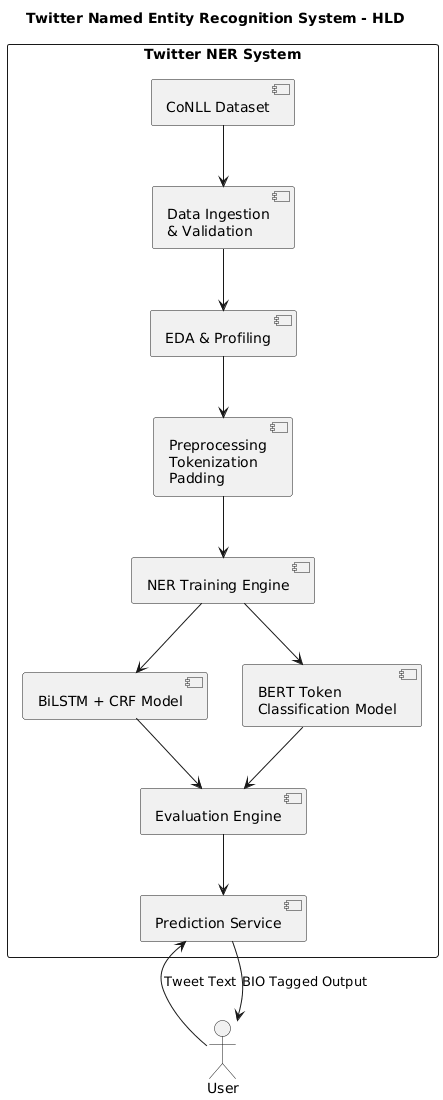

In [164]:
from IPython.display import Image
Image(filename=r"C:\Users\SamareshPradhan\Downloads\HLD_Twitter_NER.png")

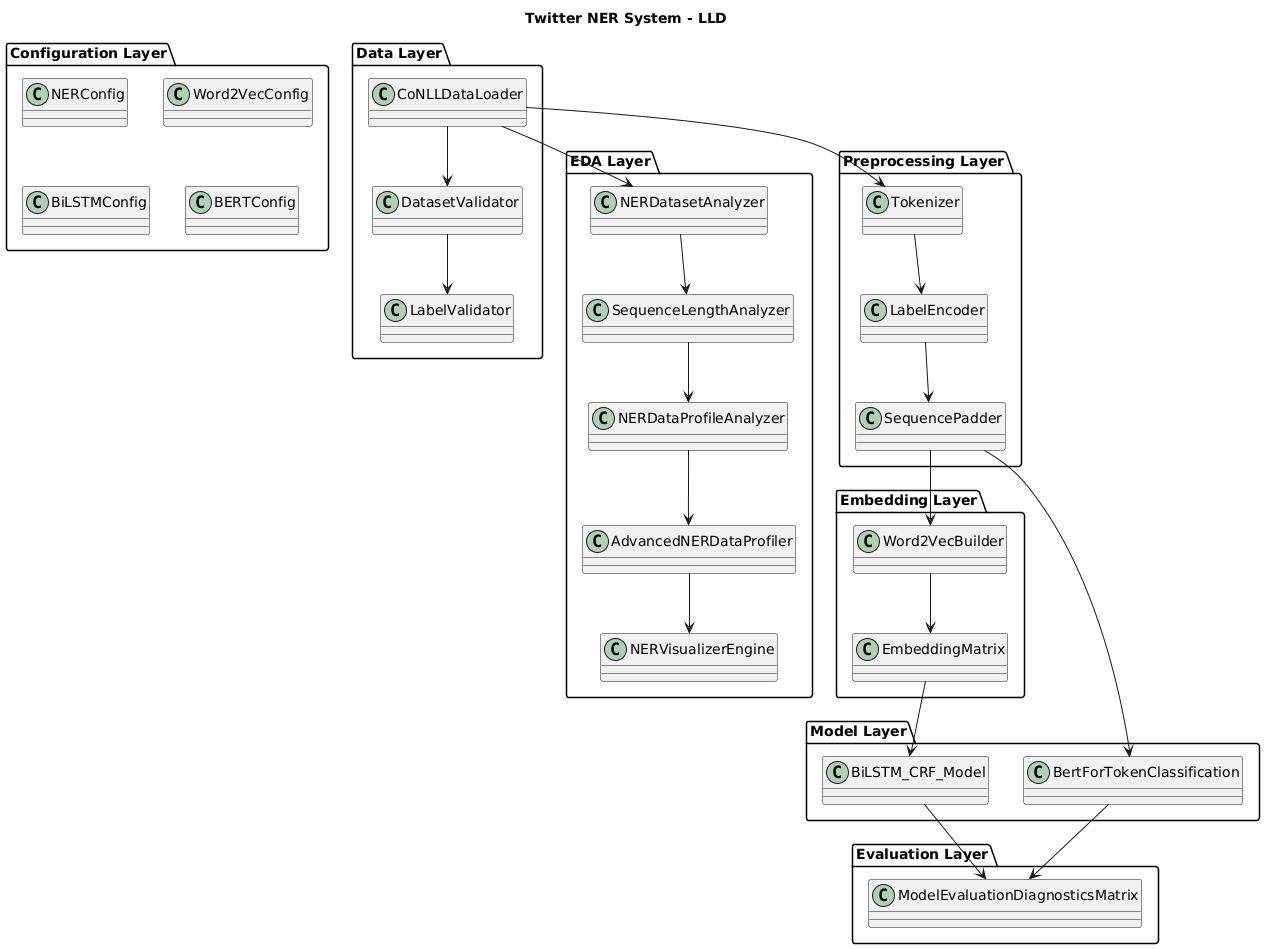

In [162]:
Image(filename=r"C:\Users\SamareshPradhan\Downloads\LLD_Twitter_NER.png")

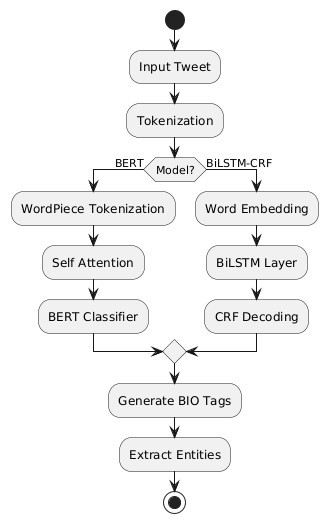

In [166]:
Image(filename=r"C:\Users\SamareshPradhan\Downloads\Production_Flow_Diagram_Twitter_NER.png")

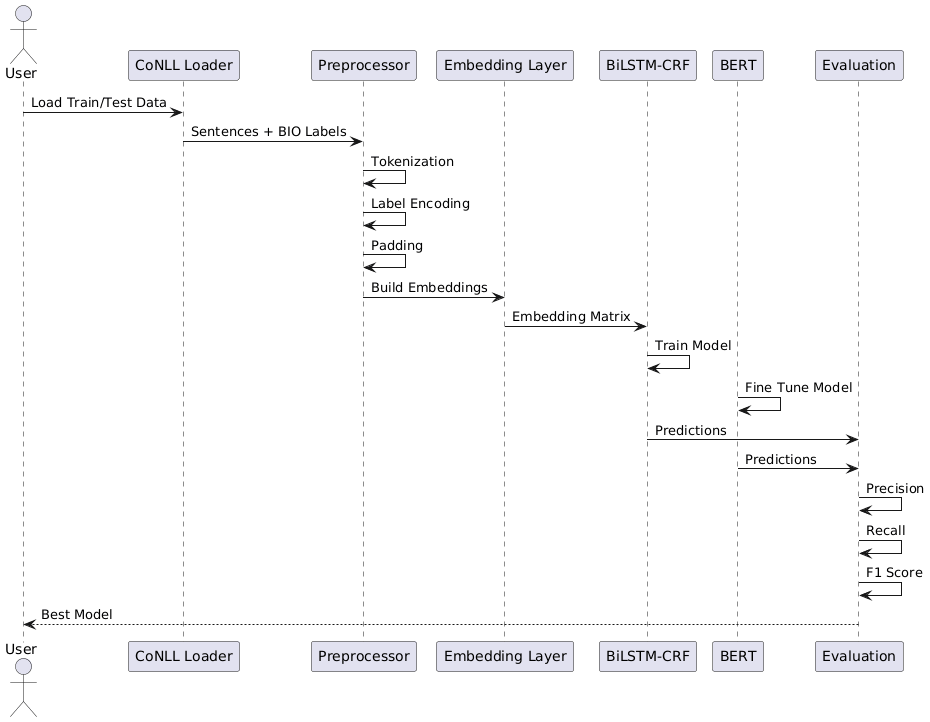

In [165]:
Image(filename=r"C:\Users\SamareshPradhan\Downloads\Sequence_Diagram_Twitter_NER.png")

In [132]:
# =============================
# Standard Library
# =============================
import os
import time
import functools
from collections import Counter
from dataclasses import dataclass
from statistics import mean
from typing import Any, Dict, List, Tuple

# =============================
# Data & Visualization
# =============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =============================
# NLP & Embeddings
# =============================
import gensim.downloader as api
from gensim.models import Word2Vec
import fasttext
import fasttext.util

# =============================
# TensorFlow / Keras
# =============================
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    Callback,
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    GRU,
    LSTM,
    Dropout,
    Dense,
    TimeDistributed
)

# =============================
# CRF & Addons
# =============================
from tensorflow_addons.layers import CRF
from tensorflow_addons.losses import SigmoidFocalCrossEntropy
from tensorflow_addons.optimizers import AdamW
from tensorflow_addons.utils.types import FloatTensorLike, TensorLike
from tensorflow.keras.preprocessing.sequence import pad_sequences

from keras_crf import CRFModel
from tf2crf import CRF as TF2CRF, ModelWithCRFLoss, ModelWithCRFLossDSCLoss


# =============================
# ML Utilities
# =============================
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from collections import defaultdict

# =============================
# Evaluation
# =============================
from seqeval.metrics import classification_report, f1_score
from transformers import AutoConfig, AutoModelForTokenClassification
from transformers import BertForTokenClassification, TrainingArguments, Trainer
from transformers import AutoTokenizer


# =============================
# Progress bar
# =============================
from tqdm import tqdm
tqdm.pandas()


In [2]:
"""
Configuration Module
====================

Centralized configuration for the Twitter NER Project.
"""


@dataclass(frozen=True)
class NERConfig:
    """
    Global configuration.
    """

    train_file_path: str

    test_file_path: str

    max_sequence_length: int = 64

    test_size: float = 0.20

    random_state: int = 42


@dataclass(frozen=True)
class Word2VecConfig:
    """
    Word2Vec configuration.
    """

    embedding_dim: int = 100

    window: int = 5

    min_count: int = 1

    workers: int = 4

    epochs: int = 20


@dataclass(frozen=True)
class BiLSTMConfig:
    """
    BiLSTM-CRF configuration.
    """

    lstm_units: int = 128

    dropout_rate: float = 0.30

    batch_size: int = 32

    epochs: int = 15

    learning_rate: float = 1e-3


@dataclass(frozen=True)
class BERTConfig:
    """
    BERT configuration.
    """

    model_name: str = "bert-base-uncased"

    max_length: int = 128

    batch_size: int = 16

    learning_rate: float = 2e-5

    epochs: int = 5

In [3]:
"""
Reusable decorators.
"""

def timer(func):
    """
    Measure execution time.
    """

    @functools.wraps(func)
    def wrapper(*args, **kwargs):

        start_time = time.time()

        result = func(*args, **kwargs)

        end_time = time.time()

        print(
            f"[TIMER] {func.__name__} "
            f"completed in "
            f"{end_time - start_time:.2f} sec"
        )

        return result

    return wrapper


def log_step(step_name: str):

    def decorator(func):

        @functools.wraps(func)
        def wrapper(*args, **kwargs):

            print("\n" + "=" * 80)
            print(f"STEP : {step_name}")
            print("=" * 80)

            return func(*args, **kwargs)

        return wrapper

    return decorator

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'figure.titlesize': 16,
    'font.family': 'sans-serif'
})

In [4]:
"""
Custom Exceptions
"""


class NERException(Exception):
    """
    Base exception for NER project.
    """

    pass


class DataValidationException(NERException):
    """
    Dataset validation errors.
    """

    pass


class LabelValidationException(NERException):
    """
    Label validation errors.
    """

    pass

In [5]:
"""
Artifacts used across pipeline.
"""

@dataclass
class DatasetArtifacts:

    sentences: List[List[str]]

    labels: List[List[str]]

    metadata: Dict


@dataclass
class TrainingArtifacts:

    model: Any

    metrics: Dict

    training_history: Dict

@dataclass
class PreprocessingArtifacts:

    word2idx: dict

    idx2word: dict

    tag2idx: dict

    idx2tag: dict

    encoded_sentences: any

    encoded_labels: any

    padded_sentences: any

    padded_labels: any

In [6]:
class CoNLLDataLoader:
    """
    Robust CoNLL format loader for NER datasets (e.g., WNUT, CoNLL 2003).
    """

    @log_step("Loading CoNLL Data")
    @timer
    def load(self, file_path: str) -> Tuple[List[List[str]], List[List[str]]]:
        """
        Load sentences and BIO tags from a CoNLL-style file.

        Each line: token label
        Sentences separated by blank lines.
        """

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"❌ File not found: {file_path}")

        sentences = []
        labels = []

        current_tokens = []
        current_tags = []

        malformed_count = 0

        with open(file_path, encoding="utf-8") as file:
            for line_num, line in enumerate(file, 1):
                line = line.strip()

                # Sentence boundary
                if not line:
                    if current_tokens:
                        sentences.append(current_tokens)
                        labels.append(current_tags)
                        current_tokens = []
                        current_tags = []
                    continue

                # Parse token + tag
                parts = line.rsplit(maxsplit=1)

                if len(parts) == 2:
                    token, tag = parts
                else:
                    # fallback for corrupted lines
                    token, tag = line, "O"
                    malformed_count += 1
                    print(f"⚠️ Malformed line {line_num}: {line}")

                current_tokens.append(token)
                current_tags.append(tag)

        # flush last sentence
        if current_tokens:
            sentences.append(current_tokens)
            labels.append(current_tags)

        total_tokens = sum(len(s) for s in sentences)

        print(
            f"✅ Loaded {len(sentences)} sentences | "
            f"{total_tokens:,} tokens | "
            f"{malformed_count} malformed lines"
        )

        return sentences, labels

    def get_label_distribution(self, labels: List[List[str]]) -> Counter:
        """
        Return frequency distribution of BIO tags.
        """
        flat_labels = [tag for sent in labels for tag in sent]
        return Counter(flat_labels)

In [134]:
class SimpleCoNLLLoader:
    """
    Lightweight yet robust CoNLL Data Loader.

    Supports:
    - Returning tuple-based samples: [(token, tag), ...]
    - Converting into (sentences, labels)
    - Basic validation and error handling
    """

    def __init__(self, encoding: str = "utf-8"):
        self.encoding = encoding

    # --------------------------------------------------
    # ✅ MAIN LOADER (Your style, improved)
    # --------------------------------------------------
    def load_samples(self, filename: str) -> List[List[Tuple[str, str]]]:
        """
        Load CoNLL file and return:
        List[List[(token, tag)]]
        """

        if not os.path.exists(filename):
            raise FileNotFoundError(f"❌ File not found: {filename}")

        samples = []
        current_sample = []
        malformed_count = 0

        with open(filename, 'r', encoding=self.encoding) as file:
            for line_num, line in enumerate(file, 1):
                line = line.strip()

                # Sentence boundary
                if not line:
                    if current_sample:
                        samples.append(current_sample)
                        current_sample = []
                    continue

                parts = line.split()

                # ✅ Robust parsing
                if len(parts) >= 2:
                    token = parts[0]
                    tag = parts[-1]
                else:
                    # fallback for malformed line
                    token = line
                    tag = "O"
                    malformed_count += 1
                    print(f"⚠️ Malformed line {line_num}: {line}")

                current_sample.append((token, tag))

        # ✅ Flush last sentence
        if current_sample:
            samples.append(current_sample)

        total_tokens = sum(len(s) for s in samples)

        print(
            f"✅ Loaded {len(samples)} samples | "
            f"{total_tokens:,} tokens | "
            f"{malformed_count} malformed lines"
        )

        return samples

    # --------------------------------------------------
    # ✅ CONVERTER (Compatible with your pipeline)
    # --------------------------------------------------
    @staticmethod
    def to_sentences_labels(
        samples: List[List[Tuple[str, str]]]
    ) -> Tuple[List[List[str]], List[List[str]]]:
        """
        Convert samples → (sentences, labels)
        """

        sentences = []
        labels = []

        for sample in samples:
            tokens = [token for token, tag in sample]
            tags = [tag for token, tag in sample]

            sentences.append(tokens)
            labels.append(tags)

        return sentences, labels

    # --------------------------------------------------
    # ✅ LABEL DISTRIBUTION
    # --------------------------------------------------
    @staticmethod
    def get_label_distribution(
        labels: List[List[str]]
    ) -> Counter:
        """
        Return frequency distribution of labels
        """
        flat_labels = [tag for seq in labels for tag in seq]
        return Counter(flat_labels)

    # --------------------------------------------------
    # ✅ SCHEMA GENERATION (your logic preserved)
    # --------------------------------------------------
    @staticmethod
    def build_schema(samples: List[List[Tuple[str, str]]]) -> List[str]:
        """
        Build schema: ['_', 'B-xxx', ...]
        """
        return ['_'] + sorted({
            tag for sentence in samples
            for _, tag in sentence
        })

    # --------------------------------------------------
    # ✅ FULL PIPELINE HELPER (one-liner usage)
    # --------------------------------------------------
    def load(
        self,
        train_path: str,
        test_path: str
    ):
        """
        Full loader pipeline:

        Returns:
        - train_samples
        - test_samples
        - train_sentences, train_labels
        - test_sentences, test_labels
        - schema
        """

        train_samples = self.load_samples(train_path)
        test_samples = self.load_samples(test_path)

        train_sentences, train_labels = self.to_sentences_labels(train_samples)
        test_sentences, test_labels = self.to_sentences_labels(test_samples)

        all_samples = train_samples + test_samples
        schema = self.build_schema(all_samples)

        return (
            train_samples,
            test_samples,
            train_sentences,
            train_labels,
            test_sentences,
            test_labels,
            schema,
        )

In [7]:
class DatasetValidator:

    @staticmethod
    @log_step("Validating Dataset Structure")
    @timer
    def validate(
        sentences,
        labels
    ) -> None:

        if len(sentences) == 0:

            raise DataValidationException(
                "No sentences found."
            )

        if len(sentences) != len(labels):

            raise DataValidationException(
                "Sentence-label mismatch."
            )

        for idx, (
            sentence,
            tags
        ) in enumerate(
            zip(sentences, labels)
        ):

            if len(sentence) != len(tags):

                raise DataValidationException(
                    f"Mismatch at index {idx}"
                )

In [8]:
class LabelValidator:

    VALID_LABELS = set()

    @classmethod
    def load_labels_from_conll(cls, file_path):
        labels = set()

        with open(file_path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()

                if line:
                    parts = line.split()

                    # last column = label
                    label = parts[-1]
                    labels.add(label)

        cls.VALID_LABELS = labels
        print(f"✅ Loaded {len(labels)} labels:")
        print(labels)

    @classmethod
    def validate(cls, labels):
        for sequence in labels:
            for tag in sequence:
                if tag not in cls.VALID_LABELS:
                    raise Exception(f"Unknown tag: {tag}")

In [9]:
class VocabularyBuilder:

    PAD_TOKEN = "<PAD>"

    UNK_TOKEN = "<UNK>"

    @classmethod
    @log_step("Building Vocabulary")
    @timer
    def build(
        cls,
        sentences,
        min_frequency: int = 1
    ):

        counter = Counter()

        for sentence in sentences:

            counter.update(sentence)

        vocabulary = {

            cls.PAD_TOKEN: 0,

            cls.UNK_TOKEN: 1
        }

        for word, freq in counter.items():

            if freq >= min_frequency:

                vocabulary[word] = (
                    len(vocabulary)
                )

        idx2word = {

            idx: word

            for word, idx
            in vocabulary.items()
        }

        return (
            vocabulary,
            idx2word
        )

In [10]:
class LabelEncoder:

    PAD_LABEL = "PAD"

    @classmethod
    @log_step("Fitting Label Encoder")
    @timer
    def fit(cls, labels):

        unique_labels = set()

        for sequence in labels:
            unique_labels.update(sequence)

        tag2idx = {
            cls.PAD_LABEL: 0
        }

        for label in sorted(unique_labels):

            tag2idx[label] = len(tag2idx)

        idx2tag = {

            idx: tag

            for tag, idx
            in tag2idx.items()
        }

        return tag2idx, idx2tag

    @staticmethod
    @log_step("Transforming Labels")
    @timer
    def transform(
        labels,
        tag2idx
    ):

        return [

            [
                tag2idx[tag]
                for tag in sequence
            ]

            for sequence in labels
        ]

    @staticmethod
    @timer
    def inverse_transform(
        encoded_labels,
        idx2tag
    ):

        return [

            [
                idx2tag[idx]
                for idx in sequence
            ]

            for sequence in encoded_labels
        ]

In [11]:
class TokenEncoder:

    @staticmethod
    @log_step("Encoding Tokens")
    @timer
    def transform(
        sentences,
        word2idx
    ):

        unk_id = word2idx["<UNK>"]

        encoded = []

        for sentence in sentences:

            encoded.append(

                [
                    word2idx.get(
                        token,
                        unk_id
                    )

                    for token
                    in sentence
                ]
            )

        return encoded

In [12]:
"""
NER Tag Encoder
===============

Encodes BIO tags into integer representations
and decodes them back into tags.
"""


class TagEncoder:

    PAD_TAG = "PAD"

    @classmethod
    def fit(
        cls,
        labels
    ):
        """
        Create tag vocabulary.

        Parameters
        ----------
        labels : List[List[str]]

        Returns
        -------
        tag2idx : dict
        idx2tag : dict
        """

        unique_tags = set()

        for sequence in labels:
            unique_tags.update(sequence)

        tag2idx = {
            cls.PAD_TAG: 0
        }

        for tag in sorted(unique_tags):

            tag2idx[tag] = len(tag2idx)

        idx2tag = {

            idx: tag

            for tag, idx
            in tag2idx.items()
        }

        return tag2idx, idx2tag

    @staticmethod
    def transform(
        labels,
        tag2idx
    ):
        """
        Convert BIO tags to integers.
        """

        return [

            [
                tag2idx[tag]
                for tag in sequence
            ]

            for sequence in labels
        ]

    @staticmethod
    def inverse_transform(
        encoded_labels,
        idx2tag
    ):
        """
        Convert integers back to BIO tags.
        """

        return [

            [
                idx2tag[idx]
                for idx in sequence
            ]

            for sequence in encoded_labels
        ]

In [13]:
class SequencePadder:

    @staticmethod
    @log_step("Padding Tokens")
    @timer
    def pad_tokens(
        encoded_sentences,
        max_length,
        pad_value=0
    ):

        padded = np.full(
            (
                len(encoded_sentences),
                max_length
            ),
            pad_value
        )

        for i, sequence in enumerate(
            encoded_sentences
        ):

            length = min(
                len(sequence),
                max_length
            )

            padded[i, :length] = (
                sequence[:length]
            )

        return padded

    @staticmethod
    @log_step("Padding Labels")
    @timer
    def pad_labels(
        encoded_labels,
        max_length,
        pad_value=0
    ):

        padded = np.full(
            (
                len(encoded_labels),
                max_length
            ),
            pad_value
        )

        for i, sequence in enumerate(
            encoded_labels
        ):

            length = min(
                len(sequence),
                max_length
            )

            padded[i, :length] = (
                sequence[:length]
            )

        return padded

In [14]:
class NERDatasetAnalyzer:

    """
    Generates descriptive statistics
    for Twitter NER datasets.
    """

    @staticmethod
    @log_step("Analyzing NER Dataset")
    @timer
    def analyze(
        sentences,
        labels
    ) -> dict:

        sentence_lengths = [
            len(sentence)
            for sentence in sentences
        ]

        vocabulary = Counter()

        label_counter = Counter()

        for sentence in sentences:

            vocabulary.update(sentence)

        for tag_sequence in labels:

            label_counter.update(tag_sequence)

        report = {

            "total_sentences":
                len(sentences),

            "average_length":
                round(
                    mean(sentence_lengths),
                    2
                ),

            "maximum_length":
                max(sentence_lengths),

            "minimum_length":
                min(sentence_lengths),

            "vocabulary_size":
                len(vocabulary),

            "unique_labels":
                len(label_counter),

            "label_distribution":
                dict(label_counter),

            "top_tokens":
                vocabulary.most_common(20)
        }

        return report

    @staticmethod
    @timer
    def print_report(
        report: dict
    ):

        print("\n" + "=" * 80)
        print("NER DATASET REPORT")
        print("=" * 80)

        print(
            f"Total Sentences : "
            f"{report['total_sentences']}"
        )

        print(
            f"Average Length  : "
            f"{report['average_length']}"
        )

        print(
            f"Maximum Length  : "
            f"{report['maximum_length']}"
        )

        print(
            f"Vocabulary Size : "
            f"{report['vocabulary_size']}"
        )

        print(
            f"Unique Labels   : "
            f"{report['unique_labels']}"
        )

        print("=" * 80)

In [15]:
class LabelDistributionAnalyzer:

    @staticmethod
    @log_step("Analyzing Label Distribution")
    @timer
    def analyze(labels):

        counter = Counter()

        for sequence in labels:

            counter.update(sequence)

        return counter

In [16]:
class SequenceLengthAnalyzer:

    @staticmethod
    @log_step("Analyzing Sequence Lengths")
    @timer
    def analyze(sentences):

        lengths = [
            len(sentence)
            for sentence in sentences
        ]

        return {
            "minimum_length": int(min(lengths)),
            "maximum_length": int(max(lengths)),
            "average_length": round(
                float(np.mean(lengths)),
                2
            ),
            "95_percentile": int(
                np.percentile(lengths, 95)
            ),
            "99_percentile": int(
                np.percentile(lengths, 99)
            )
        }

    @staticmethod
    @timer
    def print_report(report: dict):

        print("\n" + "=" * 80)
        print("SEQUENCE LENGTH ANALYSIS")
        print("=" * 80)

        print(
            f"Minimum Length      : "
            f"{report['minimum_length']}"
        )

        print(
            f"Maximum Length      : "
            f"{report['maximum_length']}"
        )

        print(
            f"Average Length      : "
            f"{report['average_length']}"
        )

        print(
            f"95th Percentile     : "
            f"{report['95_percentile']}"
        )

        print(
            f"99th Percentile     : "
            f"{report['99_percentile']}"
        )

        print("=" * 80)

In [17]:
# Set standard plotting style sheets for the project
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

class NERDataProfileAnalyzer:
    """Extracts metadata statistics, sequence configurations, and entity distributions 
    from unstructured CoNLL format token lists."""
    
    def __init__(self, sentences, labels):
        self.sentences = sentences
        self.labels = labels
        self.flat_tokens = [token for seq in sentences for token in seq]
        self.flat_labels = [label for seq in labels for label in seq]

    @timer
    @log_step("Computing Corpus Telemetry")
    def compute_corpus_telemetry(self) -> dict:
        """Calculates deep structural properties of the parsed Twitter corpus."""
        entity_tokens = [lbl for lbl in self.flat_labels if lbl != 'O']
        
        metrics = {
            "Total Sentences": len(self.sentences),
            "Total Token Count": len(self.flat_tokens),
            "Unique Vocabulary Size": len(set(self.flat_tokens)),
            "Total Entities Identified": len(entity_tokens),
            "Avg Sentence Length": np.mean([len(s) for s in self.sentences]),
            "Max Sentence Length": np.max([len(s) for s in self.sentences]),
            "Entity-to-Token Ratio (%)": (len(entity_tokens) / len(self.flat_tokens)) * 100
        }
        return metrics

    @timer
    def get_label_frequency_dataframe(self, drop_outside=False) -> pd.DataFrame:
        """Compiles class occurrences into structured dataframes for plotter routing."""
        counts = Counter(self.flat_labels)
        if drop_outside:
            counts.pop('O', None)
            
        df = pd.DataFrame(counts.items(), columns=['Entity_Class', 'Frequency'])
        return df.sort_values(by='Frequency', ascending=False).reset_index(drop=True)
    @timer
    def get_entity_density_per_sequence(self) -> list:
        """Computes the exact volume density of named annotations within each individual sentence."""
        return [sum(1 for lbl in seq if lbl != 'O') for seq in self.labels]


class NERVisualizerEngine:
    """Isolated graphics rendering matrix. Decouples business calculations from presentation layers."""
    
    @staticmethod
    @timer
    def plot_label_imbalance(analyzer: NERDataProfileAnalyzer, include_o_class=False):
        """Displays frequency distributions across different target categories."""
        df = analyzer.get_label_frequency_dataframe(drop_outside=not include_o_class)
        title = "Complete Dataset Label Imbalance" if include_o_class else "Fine-Grained Entity Category Distributions (Excluding 'O')"
        
        plt.figure(figsize=(12, 6))
        ax = sns.barplot(x='Frequency', y='Entity_Class', data=df, hue='Entity_Class', legend=False, palette='viridis')
        
        # Superimpose numeric values directly onto charts for better transparency
        for container in ax.containers:
            ax.bar_label(container, fmt='%d', padding=5, fontsize=10, color='black')
            
        plt.title(title, weight='bold', pad=15)
        plt.xlabel("Occurrences")
        plt.ylabel("BIO Class Reference Target")
        plt.tight_layout()
        plt.show()

    @staticmethod
    @timer
    def plot_sequence_length_distribution(analyzer: NERDataProfileAnalyzer):
        """Plots sequence properties to reveal structural limits for max padding selections."""
        lengths = [len(s) for s in analyzer.sentences]
        
        plt.figure(figsize=(12, 5))
        sns.histplot(lengths, kde=True, bins=30, color='#1A446C', edgecolor='black', alpha=0.7)
        
        # Draw threshold marker for hyperparameter setting visualization
        plt.axvline(np.mean(lengths), color='red', linestyle='--', label=f"Mean Length: {np.mean(lengths):.1f}")
        plt.axvline(np.percentile(lengths, 95), color='darkorange', linestyle=':', label=f"95th Percentile: {np.percentile(lengths, 95):.1f}")
        
        plt.title("Twitter Post Structural Sequence Length Distribution Profile", weight='bold', pad=15)
        plt.xlabel("Tokens Count per Sentence Array")
        plt.ylabel("Volume Frequency Density")
        plt.legend(frameon=True)
        plt.tight_layout()
        plt.show()

    @staticmethod
    @timer
    def plot_joint_density_vs_length(analyzer: NERDataProfileAnalyzer):
        """Renders relationships showing entity cluster volume against sentence spans."""
        lengths = [len(s) for s in analyzer.sentences]
        densities = analyzer.get_entity_density_per_sequence()
        
        df = pd.DataFrame({'Sentence Length': lengths, 'Entities Volume': densities})
        
        plt.figure(figsize=(10, 5))
        sns.stripplot(x='Entities Volume', y='Sentence Length', data=df, jitter=0.25, size=5, alpha=0.5, hue='Entities Volume', palette='magma', legend=False)
        plt.title("Spatial Named Entity Concentration Index Across Sentence Lengths", weight='bold', pad=15)
        plt.xlabel("Total Named Entities Found inside Sequence")
        plt.ylabel("Raw Post Character-Word Array Index Span")
        plt.tight_layout()
        plt.show()

In [18]:
# Set standard publication theme parameters
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'figure.titlesize': 16,
    'font.family': 'sans-serif'
})

class AdvancedNERDataProfiler:
    """Computes advanced telemetry matrices, sequence density metrics, 
    and word-frequency profiles across a CoNLL formatted dataset corpus."""
    
    def __init__(self, sentences: list, labels: list):
        self.sentences = sentences
        self.labels = labels
        self.flat_tokens = [token for seq in sentences for token in seq]
        self.flat_labels = [label for seq in labels for label in seq]
        self.lengths = [len(s) for s in sentences]

    @timer
    @log_step("Computing Advanced Summary Cards")
    def compute_summary_cards(self) -> dict:
        """Calculates system-wide key telemetry parameters for high-level cards."""
        entity_tokens = [lbl for lbl in self.flat_labels if lbl != 'O']
        unique_tokens = set(self.flat_tokens)
        
        return {
            "total_sequences": len(self.sentences),
            "total_tokens": len(self.flat_tokens),
            "vocabulary_size": len(unique_tokens),
            "total_entities": len(entity_tokens),
            "entity_to_token_ratio": (len(entity_tokens) / len(self.flat_tokens)) * 100,
            "lexical_diversity": (len(unique_tokens) / len(self.flat_tokens)) * 100 if len(self.flat_tokens) > 0 else 0
        }

    @timer
    def get_length_distributions(self) -> dict:
        """Computes accurate quantile splits and extreme threshold bounds for token array lengths."""
        return {
            "mean": np.mean(self.lengths),
            "median": np.median(self.lengths),
            "p95": np.percentile(self.lengths, 95),
            "p99": np.percentile(self.lengths, 99),
            "std": np.std(self.lengths)
        }

    @timer
    def get_vocabulary_profiles(self, top_n: int = 30) -> pd.DataFrame:
        """Tracks word presence metrics across corpus files to locate top tokens."""
        counts = Counter(self.flat_tokens)
        df = pd.DataFrame(counts.items(), columns=['Token', 'Frequency'])
        return df.sort_values(by='Frequency', ascending=False).head(top_n).reset_index(drop=True)

    @timer
    def get_label_frequency_distribution(self, strip_outside: bool = False) -> pd.DataFrame:
        """Compiles class frequencies into clean datasets for plotting."""
        counts = Counter(self.flat_labels)
        if strip_outside:
            counts.pop('O', None)
        df = pd.DataFrame(counts.items(), columns=['Label_Class', 'Count'])
        return df.sort_values(by='Count', ascending=False).reset_index(drop=True)


class InteractiveNERVisualizer:
    """Isolated enterprise graphics rendering pipeline engine."""

    @staticmethod
    @timer
    def display_summary_dashboard(profiler: AdvancedNERDataProfiler):
        """Prints a clean text-based telemetry summary card profile."""
        cards = profiler.compute_summary_cards()
        print("\n" + "="*60 + "\n" + " "*15 + "DATASET METRICS RUNTIME OVERVIEW" + "\n" + "="*60)
        print(f" 📋 Total Sentences Evaluated : {cards['total_sequences']:,}")
        print(f" 🔤 Total Word Tokens Parsed  : {cards['total_tokens']:,}")
        print(f" 📑 Unique System Vocabulary  : {cards['vocabulary_size']:,}")
        print(f" 🏷️  Identified Target Entities : {cards['total_entities']:,}")
        print(f" 📊 Named Entity Density Ratio: {cards['entity_to_token_ratio']:.2f}%")
        print(f" 🧩 Lexical Diversity Metrics : {cards['lexical_diversity']:.2f}%")
        print("="*60 + "\n")

    @staticmethod
    @timer
    def plot_sequence_length_matrix(profiler: AdvancedNERDataProfiler):
        """Renders an integrated layout containing a sequence Length Histogram, 

        Boxplot, and Cumulative Distribution Function (CDF)."""
        lengths = profiler.lengths
        stats_meta = profiler.get_length_distributions()

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Plot 1: Length Histogram Distribution Bounds
        sns.histplot(lengths, kde=True, bins=30, ax=axes[0], color='#1A446C', edgecolor='black', alpha=0.7)
        axes[0].axvline(stats_meta['mean'], color='red', linestyle='--', label=f"Mean: {stats_meta['mean']:.1f}")
        axes[0].set_title("Sequence Length Histogram")
        axes[0].set_xlabel("Words per Sentence")
        axes[0].set_ylabel("Frequency Density")
        axes[0].legend()

        # Plot 2: Length Outlier Boxplot Profiles
        sns.boxplot(x=lengths, ax=axes[1], color='#4A90E2', flierprops={"marker": "x", "markerfacecolor": "red"})
        axes[1].set_title("Sequence Length Boxplot")
        axes[1].set_xlabel("Words per Sentence Outlier Span")

        # Plot 3: Empirical Cumulative Distribution Function (CDF Curve)
        sorted_lengths = np.sort(lengths)
        cdf = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths)
        axes[2].plot(sorted_lengths, cdf, label='Empirical CDF', color='darkgreen', lw=2)
        axes[2].axhline(0.95, color='darkorange', linestyle=':', label=f"95% Coverage Boundary ({int(stats_meta['p95'])} words)")
        axes[2].set_title("Length Cumulative Distribution Function (CDF)")
        axes[2].set_xlabel("Words per Sentence")
        axes[2].set_ylabel("Probability Coverage Split")
        axes[2].legend()

        plt.suptitle("Comprehensive Dataset Text Length Analysis Framework", y=1.02, weight='bold')
        plt.tight_layout()
        plt.show()

    @staticmethod
    @timer
    def plot_vocabulary_frequency_bars(profiler: AdvancedNERDataProfiler, top_n: int = 20):
        """Renders word frequency profiles across the parsed corpus tokens."""
        df = profiler.get_vocabulary_profiles(top_n=top_n)
        
        plt.figure(figsize=(14, 5))
        ax = sns.barplot(x='Frequency', y='Token', data=df, hue='Token', legend=False, palette='mako')
        
        for container in ax.containers:
            ax.bar_label(container, fmt='%d', padding=3, fontsize=9)
            
        plt.title(f"Top {top_n} Most Frequent Vocabulary Tokens Across Corpus Files", weight='bold', pad=15)
        plt.xlabel("Occurrences Count")
        plt.ylabel("Extracted Token String")
        plt.tight_layout()
        plt.show()

    @staticmethod
    @timer
    def plot_label_distribution_matrix(profiler: AdvancedNERDataProfiler):
        """Displays side-by-side distributions comparing all classes versus 

        fine-grained named entities alone."""
        df_all = profiler.get_label_frequency_distribution(strip_outside=False)
        df_entities = profiler.get_label_frequency_distribution(strip_outside=True)

        fig, axes = plt.subplots(1, 2, figsize=(18, 6))

        # Left Axis: Complete System Distribution (Including 'O' Class)
        sns.barplot(x='Count', y='Label_Class', data=df_all, ax=axes[0], hue='Label_Class', legend=False, palette='viridis')
        axes[0].set_title("Complete Label Distribution Map (Including 'O')")
        axes[0].set_xlabel("Occurrences")
        axes[0].set_xscale('log') # Logarithmic view to make small entity classes visible alongside huge 'O' counts
        axes[0].set_ylabel("BIO Target Classes")

        # Right Axis: Fine-Grained Entities Matrix (Excluding 'O' Class)
        sns.barplot(x='Count', y='Label_Class', data=df_entities, ax=axes[1], hue='Label_Class', legend=False, palette='rocket')
        axes[1].set_title("Fine-Grained Named Entities Distribution (Excluding 'O')")
        axes[1].set_xlabel("Occurrences")
        axes[1].set_ylabel("")

        for ax in axes:
            for container in ax.containers:
                ax.bar_label(container, fmt='%d', padding=5, fontsize=9)

        plt.suptitle("Dataset Named Entity Recognition Classification Matrix", y=1.02, weight='bold')
        plt.tight_layout()
        plt.show()

In [19]:
class ModelEvaluationDiagnosticsMatrix:
    """Prepared class layer for tracking validation metrics, handling confusion matrices, 
    and generating clean prediction views."""

    @staticmethod
    @timer
    def plot_confusion_matrix(y_true: list, y_pred: list, unique_labels: list):
        """Generates a normalized heatmap of the confusion matrix to expose model error patterns."""
        from sklearn.metrics import confusion_matrix
        
        cm = confusion_matrix(y_true, y_pred, labels=unique_labels)
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        plt.figure(figsize=(12, 10))
        sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
                    xticklabels=unique_labels, yticklabels=unique_labels)
        plt.title("Normalized Confusion Matrix Heatmap (Token Classification Level)", weight='bold', pad=15)
        plt.xlabel("Predicted Label")
        plt.ylabel("True Gold Label Target")
        plt.tight_layout()
        plt.show()

    @staticmethod
    @timer
    def display_prediction_comparison(sentence: list, true_tags: list, pred_tags: list):
        """Prints a color-coded token alignment comparison between ground truth labels 

        and model predictions."""
        print(f"{'Token':<18} | {'Ground Truth Tag':<20} | {'Predicted Tag':<20}")
        print("-" * 65)
        for token, true_t, pred_t in zip(sentence, true_tags, pred_tags):
            status = "✅" if true_t == pred_t else "❌"
            print(f"{token:<18} | {true_t:<20} | {pred_t:<20} {status}")

In [135]:
TRAIN_PATH = "C:/Users/SamareshPradhan/Downloads/Twitter-NER-System/wnut 16.txt.conll"

TEST_PATH = "C:/Users/SamareshPradhan/Downloads/Twitter-NER-System/wnut 16test.txt.conll"

LabelValidator.load_labels_from_conll(TRAIN_PATH)

loader = SimpleCoNLLLoader()

train_samples, test_samples, train_sentences, train_labels, test_sentences, test_labels, schema = loader.load(TRAIN_PATH, TEST_PATH)

# train_sentences, train_labels = loader.load(TRAIN_PATH)
# test_sentences, test_labels = loader.load(TEST_PATH)

# train_samples = list(zip(train_sentences, train_labels))
# test_samples = list(zip(test_sentences, test_labels))

all_labels = train_labels + test_labels

# schema = ["_"] + sorted(
#     {tag for sentence in all_labels for tag in sentence})

# loader = CoNLLDataLoader()

DatasetValidator.validate(
    train_sentences,
    train_labels
)

LabelValidator.validate(
    train_labels
)

report = (
    NERDatasetAnalyzer
    .analyze(
        train_sentences,
        train_labels
    )
)

NERDatasetAnalyzer.print_report(
    report
)

word2idx, idx2word = (
    VocabularyBuilder.build(
        train_sentences
    )
)

tag2idx, idx2tag = (
    LabelEncoder.fit(
        train_labels
    )
)

encoded_sentences = (
    TokenEncoder.transform(
        train_sentences,
        word2idx
    )
)

encoded_labels = (
    LabelEncoder.transform(
        train_labels,
        tag2idx
    )
)

X = SequencePadder.pad_tokens(
    encoded_sentences,
    64
)

y = SequencePadder.pad_labels(
    encoded_labels,
    64
)

print(X.shape)
print(y.shape)

✅ Loaded 21 labels:
{'B-tvshow', 'B-sportsteam', 'B-product', 'I-other', 'B-facility', 'B-movie', 'B-company', 'I-company', 'O', 'I-tvshow', 'I-geo-loc', 'B-person', 'I-facility', 'I-person', 'I-sportsteam', 'I-product', 'B-other', 'I-musicartist', 'B-musicartist', 'B-geo-loc', 'I-movie'}
✅ Loaded 2394 samples | 46,469 tokens | 0 malformed lines
✅ Loaded 3850 samples | 61,908 tokens | 0 malformed lines

STEP : Validating Dataset Structure
[TIMER] validate completed in 0.00 sec

STEP : Analyzing NER Dataset
[TIMER] analyze completed in 0.05 sec

NER DATASET REPORT
Total Sentences : 2394
Average Length  : 19.41
Maximum Length  : 39
Vocabulary Size : 10586
Unique Labels   : 21
[TIMER] print_report completed in 0.00 sec

STEP : Building Vocabulary
[TIMER] build completed in 0.02 sec

STEP : Fitting Label Encoder
[TIMER] fit completed in 0.00 sec

STEP : Encoding Tokens
[TIMER] transform completed in 0.02 sec

STEP : Transforming Labels
[TIMER] transform completed in 0.01 sec

STEP : Paddin

In [136]:
train_sentences[1]

['Made',
 'it',
 'back',
 'home',
 'to',
 'GA',
 '.',
 'It',
 'sucks',
 'not',
 'to',
 'be',
 'at',
 'Disney',
 'world',
 ',',
 'but',
 'its',
 'good',
 'to',
 'be',
 'home',
 '.',
 'Time',
 'to',
 'start',
 'planning',
 'the',
 'next',
 'Disney',
 'World',
 'trip',
 '.']

In [137]:
train_labels[1]

['O',
 'O',
 'O',
 'O',
 'O',
 'B-geo-loc',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'B-facility',
 'I-facility',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'B-facility',
 'I-facility',
 'O',
 'O']

In [138]:
X[1]

array([14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 18,  6, 24, 25, 26, 27, 28,
       29, 30, 18,  6, 17, 20, 31, 18, 32, 33, 34, 35, 25, 36, 37, 20,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0])

In [139]:
y[1]

array([21, 21, 21, 21, 21,  3, 21, 21, 21, 21, 21, 21, 21,  2, 12, 21, 21,
       21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21,  2, 12, 21, 21,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0])

In [140]:
# Select the first sentence (row 0)
sentence_X = X[1]
sentence_y = y[1]

# Decode ignoring padding (0)
decoded_words = [idx2word[i] for i in sentence_X if i != 0]
decoded_tags = [idx2tag[i] for i in sentence_y if i != 0]

# Combine back to token-tag pairs
list(zip(decoded_words, decoded_tags))

[('Made', 'O'),
 ('it', 'O'),
 ('back', 'O'),
 ('home', 'O'),
 ('to', 'O'),
 ('GA', 'B-geo-loc'),
 ('.', 'O'),
 ('It', 'O'),
 ('sucks', 'O'),
 ('not', 'O'),
 ('to', 'O'),
 ('be', 'O'),
 ('at', 'O'),
 ('Disney', 'B-facility'),
 ('world', 'I-facility'),
 (',', 'O'),
 ('but', 'O'),
 ('its', 'O'),
 ('good', 'O'),
 ('to', 'O'),
 ('be', 'O'),
 ('home', 'O'),
 ('.', 'O'),
 ('Time', 'O'),
 ('to', 'O'),
 ('start', 'O'),
 ('planning', 'O'),
 ('the', 'O'),
 ('next', 'O'),
 ('Disney', 'B-facility'),
 ('World', 'I-facility'),
 ('trip', 'O'),
 ('.', 'O')]

In [141]:
distribution = (
    LabelDistributionAnalyzer
    .analyze(train_labels)
)

for tag, count in sorted(
    distribution.items()
):
    print(tag, count)


STEP : Analyzing Label Distribution
[TIMER] analyze completed in 0.00 sec
B-company 171
B-facility 104
B-geo-loc 276
B-movie 34
B-musicartist 55
B-other 225
B-person 449
B-product 97
B-sportsteam 51
B-tvshow 34
I-company 36
I-facility 105
I-geo-loc 49
I-movie 46
I-musicartist 61
I-other 320
I-person 215
I-product 80
I-sportsteam 23
I-tvshow 31
O 44007


In [142]:
report = (
    SequenceLengthAnalyzer
    .analyze(train_sentences)
)

SequenceLengthAnalyzer.print_report(
    report
)


STEP : Analyzing Sequence Lengths
[TIMER] analyze completed in 0.02 sec

SEQUENCE LENGTH ANALYSIS
Minimum Length      : 1
Maximum Length      : 39
Average Length      : 19.41
95th Percentile     : 31
99th Percentile     : 34
[TIMER] print_report completed in 0.00 sec


In [143]:
tag2idx, idx2tag = (
    TagEncoder.fit(
        train_labels
    )
)

print("\n" + "=" * 80)
print("TAG ENCODER SUMMARY")
print("=" * 80)

print(f"Total Tags Found : {len(tag2idx)}")

print("\nTag to Index Mapping:")
for tag, idx in tag2idx.items():
    print(f"{tag:<20} -> {idx}")

print("\nIndex to Tag Mapping:")
for idx, tag in idx2tag.items():
    print(f"{idx:<5} -> {tag}")


print("=" * 80)


TAG ENCODER SUMMARY
Total Tags Found : 22

Tag to Index Mapping:
PAD                  -> 0
B-company            -> 1
B-facility           -> 2
B-geo-loc            -> 3
B-movie              -> 4
B-musicartist        -> 5
B-other              -> 6
B-person             -> 7
B-product            -> 8
B-sportsteam         -> 9
B-tvshow             -> 10
I-company            -> 11
I-facility           -> 12
I-geo-loc            -> 13
I-movie              -> 14
I-musicartist        -> 15
I-other              -> 16
I-person             -> 17
I-product            -> 18
I-sportsteam         -> 19
I-tvshow             -> 20
O                    -> 21

Index to Tag Mapping:
0     -> PAD
1     -> B-company
2     -> B-facility
3     -> B-geo-loc
4     -> B-movie
5     -> B-musicartist
6     -> B-other
7     -> B-person
8     -> B-product
9     -> B-sportsteam
10    -> B-tvshow
11    -> I-company
12    -> I-facility
13    -> I-geo-loc
14    -> I-movie
15    -> I-musicartist
16    -> I-other
17    -


STEP : Computing Corpus Telemetry
[TIMER] compute_corpus_telemetry completed in 0.01 sec

   TEXT CORPUS TELEMETRY METRICS SUMMARY
-> Total Sentences                : 2394
-> Total Token Count              : 46469
-> Unique Vocabulary Size         : 10586
-> Total Entities Identified      : 2462
-> Avg Sentence Length            : 19.41
-> Max Sentence Length            : 39
-> Entity-to-Token Ratio (%)      : 5.30



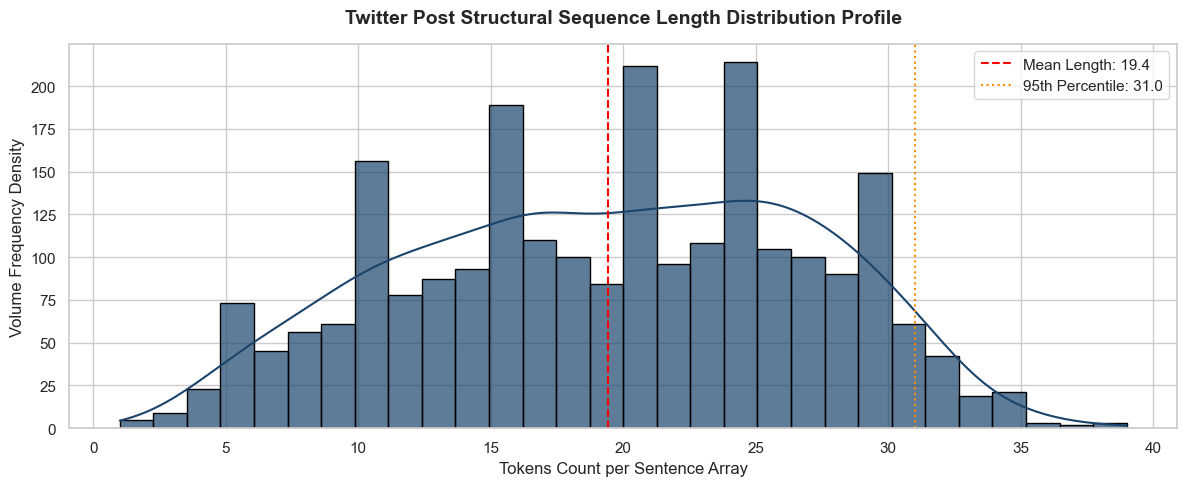

[TIMER] plot_sequence_length_distribution completed in 1.23 sec
[TIMER] get_label_frequency_dataframe completed in 0.01 sec


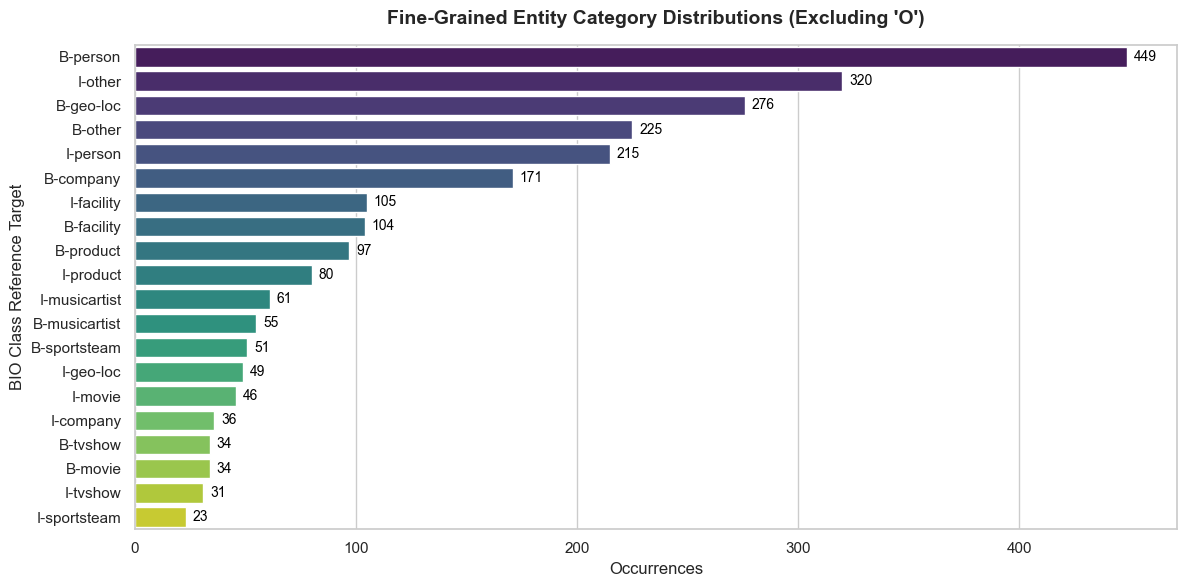

[TIMER] plot_label_imbalance completed in 0.65 sec
[TIMER] get_entity_density_per_sequence completed in 0.00 sec


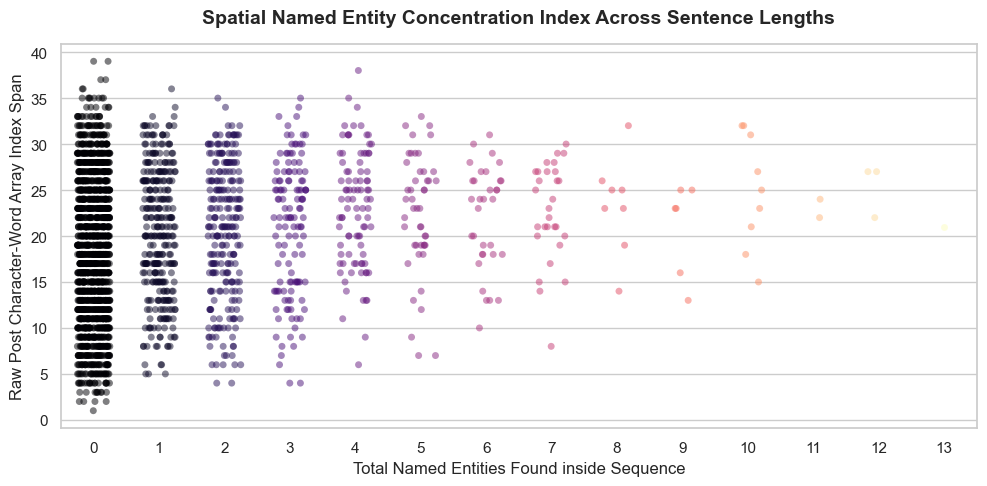

[TIMER] plot_joint_density_vs_length completed in 0.50 sec


In [144]:
# train_sentences, train_labels = parser.read_conll_file()

# 1. Instantiate the Pipeline Analyzer Wrapper
profile_analyzer = NERDataProfileAnalyzer(train_sentences, train_labels)

# 2. Output telemetry reports to text console
telemetry = profile_analyzer.compute_corpus_telemetry()
print("\n" + "="*50 + "\n   TEXT CORPUS TELEMETRY METRICS SUMMARY\n" + "="*50)
for key, value in telemetry.items():
    if isinstance(value, float):
        print(f"-> {key:<30} : {value:.2f}")
    else:
        print(f"-> {key:<30} : {value}")
print("="*50 + "\n")

# 3. Call Visualizer Engines for immediate insight delivery
# Profile 1: Review sequence patterns to choose optimal truncation padding bounds (MAX_LEN)
NERVisualizerEngine.plot_sequence_length_distribution(profile_analyzer)

# Profile 2: Detect structural target label imbalances
NERVisualizerEngine.plot_label_imbalance(profile_analyzer, include_o_class=False)

# Profile 3: Inspect cluster concentration patterns within noisy short texts
NERVisualizerEngine.plot_joint_density_vs_length(profile_analyzer)


STEP : Computing Advanced Summary Cards
[TIMER] compute_summary_cards completed in 0.01 sec

               DATASET METRICS RUNTIME OVERVIEW
 📋 Total Sentences Evaluated : 2,394
 🔤 Total Word Tokens Parsed  : 46,469
 📑 Unique System Vocabulary  : 10,586
 🏷️  Identified Target Entities : 2,462
 📊 Named Entity Density Ratio: 5.30%
 🧩 Lexical Diversity Metrics : 22.78%

[TIMER] display_summary_dashboard completed in 0.01 sec
[TIMER] get_length_distributions completed in 0.00 sec


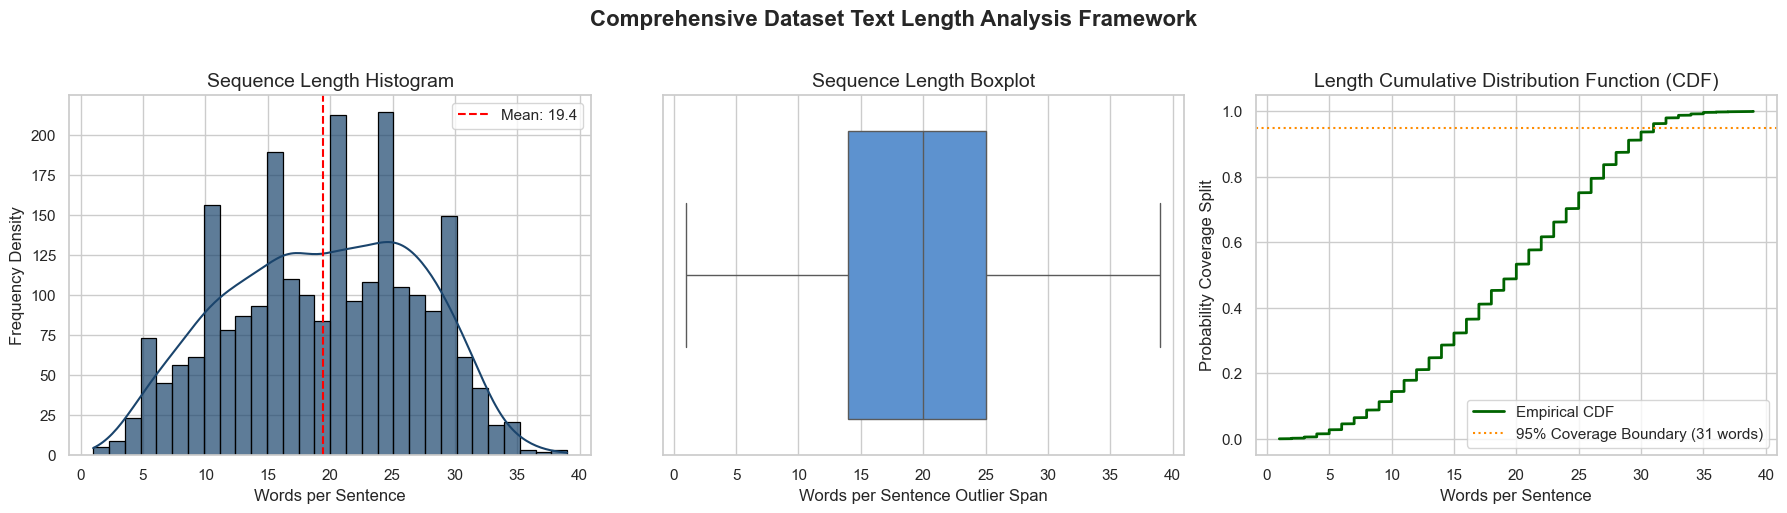

[TIMER] plot_sequence_length_matrix completed in 0.87 sec
[TIMER] get_vocabulary_profiles completed in 0.02 sec


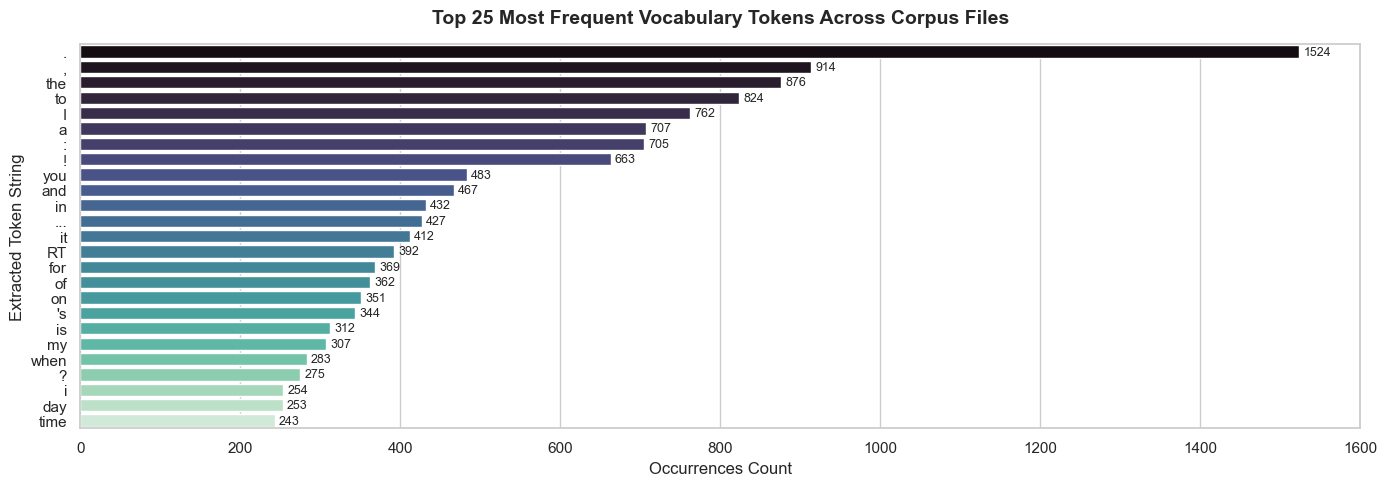

[TIMER] plot_vocabulary_frequency_bars completed in 0.74 sec
[TIMER] get_label_frequency_distribution completed in 0.01 sec
[TIMER] get_label_frequency_distribution completed in 0.00 sec


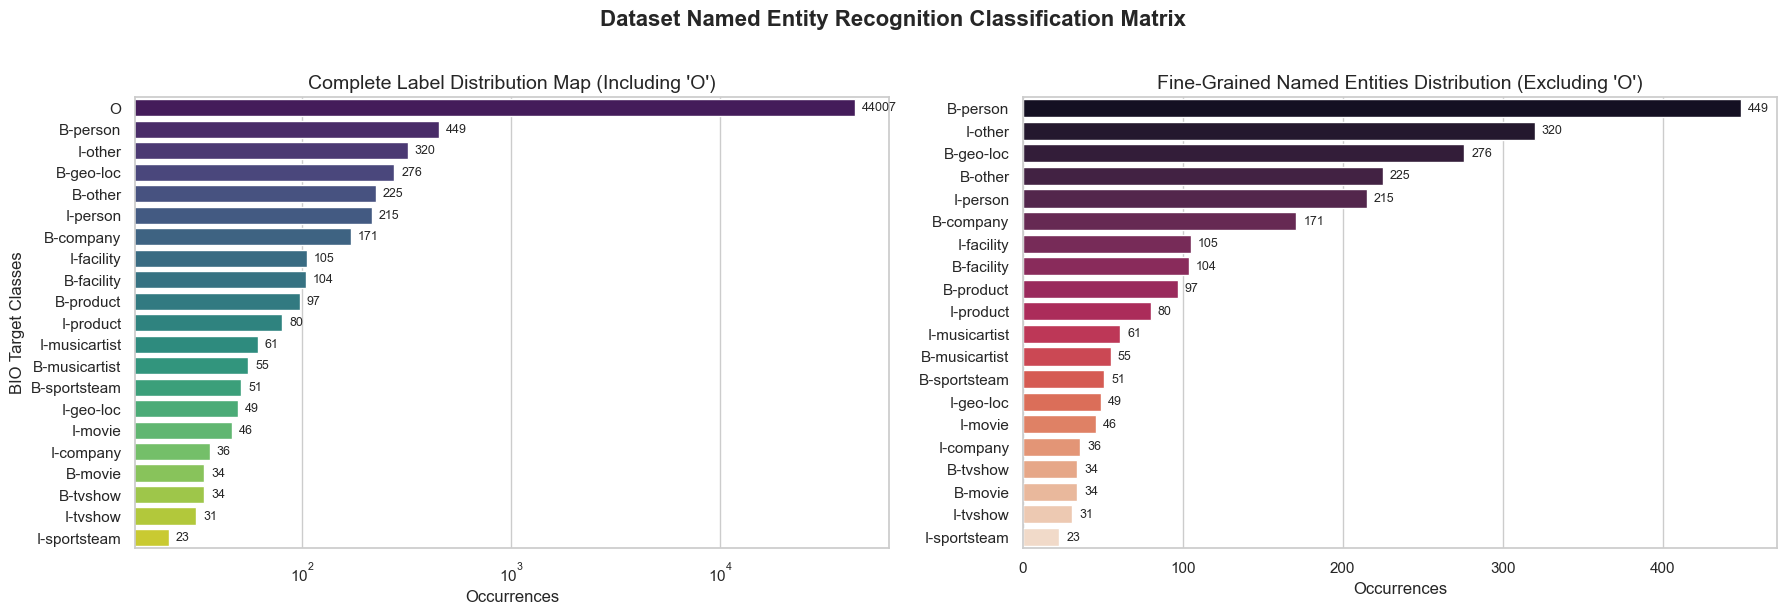

[TIMER] plot_label_distribution_matrix completed in 1.26 sec


In [145]:
# 1. Instantiate the Advanced Profiler Module
advanced_profiler = AdvancedNERDataProfiler(train_sentences, train_labels)

# 2. Render Overview Dashboard Cards 
InteractiveNERVisualizer.display_summary_dashboard(advanced_profiler)

# 3. Generate Unified Length Analysis Interface (Histogram, Boxplot, CDF Curve)
InteractiveNERVisualizer.plot_sequence_length_matrix(advanced_profiler)

# 4. Generate Vocabulary Profile Distribution Charts
InteractiveNERVisualizer.plot_vocabulary_frequency_bars(advanced_profiler, top_n=25)

# 5. Generate Target Entity Classification Analysis Diagrams
InteractiveNERVisualizer.plot_label_distribution_matrix(advanced_profiler)

<Axes: xlabel='keys'>

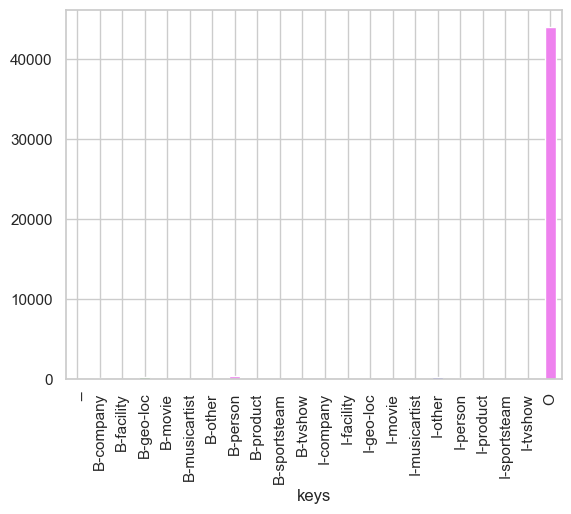

In [146]:
colors = ['violet', 'indigo', 'blue', 'green', 'yellow', 'orange', 'red']
counts = {}

# initialize
for tag in schema:
    counts[tag] = 0

# count labels correctly
for labels in train_labels:
    for tag in labels:
        counts[tag] += 1

counts_df = pd.DataFrame({
    'keys': list(counts.keys()),
    'values': list(counts.values())
})

counts_df.plot.bar(
    x='keys',
    y='values',
    legend=False,
    color=colors
)

<Axes: xlabel='keys'>

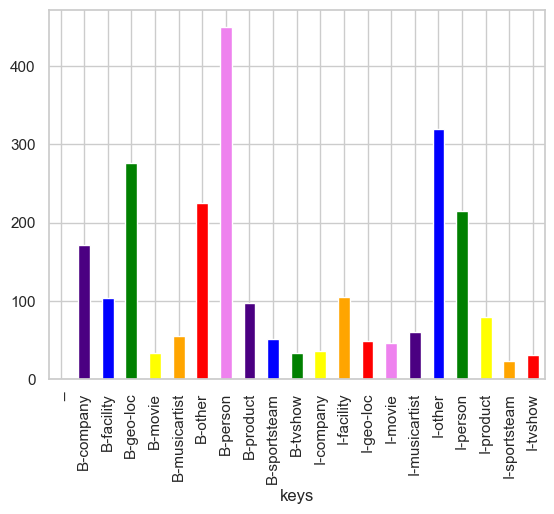

In [147]:
counts.pop('O')
counts_df = pd.DataFrame({'keys': list(counts.keys()), 'values': list(counts.values())})
counts_df.plot.bar(x='keys', y='values', legend=False, color=colors)

In [148]:
all_samples = samples

word_counts = defaultdict(int) # Calculate vocab size
max_len = 0 # Calculate max length of a sentence

for sample in all_samples:
  for word in sample:
    word_counts[word[0]]+=1

  max_len = max(max_len, len(sample))

n_words = len(word_counts.items())


print("*"*30)
print("Max Length: ", max_len)
print("Vocab Size: ", n_words)

******************************
Max Length:  39
Vocab Size:  25382


In [149]:
class Word2VecBuilder:
    """
    Optimized version: uses pretrained embeddings (GloVe, FastText, etc.)
    while keeping the same interface as the old Word2VecBuilder.
    """

    @staticmethod
    def train(
        sentences,            # list of list of tokens
        embedding_dim=200,
        pretrained_name="glove-twitter-200",
        tokenizer_num_words=None
    ):
        """
        Instead of training Word2Vec from scratch, we:
        1. Load pretrained embeddings
        2. Build a tokenizer from sentences
        3. Create an embedding matrix
        """

        # --------------------------
        # 1. Load pretrained embeddings
        # --------------------------
        print(f"[INFO] Loading pretrained embeddings: {pretrained_name}")
        word_vectors = api.load(pretrained_name)

        # --------------------------
        # 2. Build tokenizer
        # --------------------------
        all_sentences = [[token for token in sentence] for sentence in sentences]

        tokenizer = tf.keras.preprocessing.text.Tokenizer(
            num_words=tokenizer_num_words,
            lower=True
        )
        tokenizer.fit_on_texts(all_sentences)
        print(f"[INFO] Tokenizer vocabulary size: {len(tokenizer.word_index)}")

        # --------------------------
        # 3. Build embedding matrix
        # --------------------------
        num_tokens = len(tokenizer.word_index) + 1
        embedding_matrix = np.zeros((num_tokens, embedding_dim))

        hits, misses = 0, 0
        missed_words = []

        for word, i in tokenizer.word_index.items():
            if word in word_vectors:
                embedding_matrix[i] = word_vectors[word]
                hits += 1
            else:
                missed_words.append(word)
                misses += 1

        print(f"[INFO] Converted {hits} words ({misses} misses)")

        # --------------------------
        # 4. Return a dict-like model
        # --------------------------
        # To mimic Word2Vec behavior: model.wv[word]
        class DummyModel:
            def __init__(self, tokenizer, embedding_matrix):
                self.wv = {}
                self.embedding_matrix = embedding_matrix
                self.tokenizer = tokenizer
                # create a word->vector mapping
                for word, idx in tokenizer.word_index.items():
                    self.wv[word] = embedding_matrix[idx]

            def __len__(self):
                return len(self.wv)

        model = DummyModel(tokenizer, embedding_matrix)
        print(f"[INFO] Dummy Word2Vec model ready with {len(model)} words")

        return model, embedding_matrix, tokenizer

In [39]:
word2vec = api.load("glove-twitter-200") # Loading glove-twitter model
embedding_dim = 200

In [40]:
all_sentences = [] # Concating test, train sentences. To train a tokenizer
for sample in all_samples:
  sentence = [tag[0] for tag in sample]
  all_sentences.append(sentence)

crf_tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=n_words, lower=True)
crf_tokenizer.fit_on_texts(all_sentences)

In [41]:
num_tokens = len(crf_tokenizer.word_index) + 1
hits = 0
misses = 0
missed_words = []


# Prepare embedding matrix
embedding_matrix = np.zeros((num_tokens, embedding_dim))
for word, i in crf_tokenizer.word_index.items():
  embedding_vector = None
  try:
    embedding_vector = word2vec[word]
  except Exception :
    pass

  if embedding_vector is not None:
    # Words not found in embedding index will be all-zeros.
    # This includes the representation for "padding" and "OOV"
    embedding_matrix[i] = embedding_vector
    hits += 1
  else:
    missed_words.append(word)
    misses += 1
print("Converted %d words (%d misses)" % (hits, misses))

Converted 11495 words (10438 misses)


LSTM + CRF Training Model

In [42]:
tag2id = {} # Label to indicies mapping
id2tag = {} # Index to label mapping
for i, tag in enumerate(schema):
  tag2id[tag] = i
  id2tag[i] = tag

In [43]:
unique_tags = set()

for sample in train_samples:
    for word, tag in sample:
        unique_tags.add(tag)

schema = list(unique_tags)

In [44]:
tag2id = {tag: i for i, tag in enumerate(schema)}
id2tag = {i: tag for tag, i in tag2id.items()}

In [45]:
def get_dataset(samples, max_len, tag2id, tokenizer):
  '''Prepares the input dataset

  Args:
    `samples`: List[List[Tuple[word, tag]]], input data
    `max_len`: Maximum input length
    `tag2id`: Mapping[tag: integer]
    `tokenizer`: Tensorflow tokenizer, for tokenizing input sequence

  Returns:
    Tuple[np.ndarray, np.ndarray]: sentences and it's labels
  '''
  dataset = {'samples':[], 'labels': []}

  for sample in samples:
    # Extracting inputs and labels
    inputs = [x[0] for x in sample]
    outputs = [x[1] for x in sample]

    # Tokenizing inputs
    inputs = tokenizer.texts_to_sequences([inputs])[0]

    # padding labels
    padded_inputs = [inputs[i] if i < len(inputs) else 0 for i in range(max_len)]

    # Initializing labels as One Hot Encoded Vectors
    padded_labels = [[0 for i in range(len(tag2id))] for j in range(max_len)]
    for i in range(len(outputs)):
      padded_labels[i][tag2id[outputs[i]]] = 1

    # Adding padded inputs & labels to dataset
    dataset['samples'].append(padded_inputs)
    dataset['labels'].append(padded_labels)

  return np.array(dataset['samples']), np.array(dataset['labels'])

train_sentences, train_labels = get_dataset(train_samples, max_len, tag2id, crf_tokenizer)
test_sentences, test_labels = get_dataset(test_samples, max_len, tag2id, crf_tokenizer)

Training Model

In [46]:
def build_model():
  # Model definition
  input = Input(shape=(max_len,))

  # Get embeddings
  embeddings = Embedding(input_dim=embedding_matrix.shape[0],
                      output_dim=embedding_dim,
                      input_length=max_len, mask_zero=True,
                      embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix)
                    )(input)

  # variational biLSTM
  output_sequences = Bidirectional(LSTM(units=50, return_sequences=True))(embeddings)

  # Stacking
  output_sequences = Bidirectional(LSTM(units=50, return_sequences=True))(output_sequences)

  # Adding more non-linearity
  dense_out = TimeDistributed(Dense(25, activation="relu"))(output_sequences)

  # CRF layer
  crf = CRF(len(schema), name='crf')
  predicted_sequence, potentials, sequence_length, crf_kernel = crf(dense_out)

  model = Model(input, potentials)
  model.compile(
      optimizer=AdamW(weight_decay=0.001),
      loss= SigmoidFocalCrossEntropy()) # Sigmoid focal cross entropy loss

  return model

model = build_model()

# Checkpointing
save_model = tf.keras.callbacks.ModelCheckpoint(filepath='twitter_ner_crf.h5',
  monitor='val_loss',
  save_weights_only=True,
  save_best_only=True,
  verbose=1
)

# Early stoppings
es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', verbose=1, patience=1)

callbacks = [save_model, es]

model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 39)]              0         
                                                                 
 embedding (Embedding)       (None, 39, 200)           4386800   
                                                                 
 bidirectional (Bidirection  (None, 39, 100)           100400    
 al)                                                             
                                                                 
 bidirectional_1 (Bidirecti  (None, 39, 100)           60400     
 onal)                                                           
                                                                 
 time_distributed (TimeDist  (None, 39, 25)            2525      
 ributed)                                                        
                                                            

Training Our Model

In [47]:
model.fit(train_sentences, train_labels,
          validation_data = (test_sentences, test_labels),
          epochs = 15,
          callbacks  = callbacks,
          shuffle=True)

Epoch 1/15

75/75 [==============================] - ETA: 0s - loss: 0.1187
Epoch 1: val_loss improved from inf to 0.07988, saving model to twitter_ner_crf.h5
75/75 [==============================] - 38s 183ms/step - loss: 0.1187 - val_loss: 0.0799
Epoch 2/15
74/75 [============================>.] - ETA: 0s - loss: 0.0425
Epoch 2: val_loss did not improve from 0.07988
75/75 [==============================] - 5s 69ms/step - loss: 0.0427 - val_loss: 0.0889
Epoch 2: early stopping


Let's load the best model

In [48]:
model.load_weights('twitter_ner_crf.h5')

In [49]:
crf_model = tf.keras.Model(inputs=model.input, outputs=[model.output, model.get_layer('crf').output, model.input])

### Let's calculate average accuracy of the model on test set


In [50]:
def calculate_accuracy(y_true, y_pred):
  '''Convert categorical one hot encodings to indices and compute accuracy

  Args:
    `y_true`: true values
    `y_pred`: model predictions

  Returns:
    Integer, accuracy of prediction
  '''
  acc_metric = tf.keras.metrics.Accuracy()
  y_true = tf.argmax(y_true, axis=-1)
  return acc_metric(y_true, y_pred).numpy().item()

def calculate_mosacy(crf_model, test_sentences, test_labels):
  '''Calculates average validation accuracy of model'''

  # Batch the dataset
  batched_validation_set = tf.data.Dataset.from_tensor_slices((test_sentences, test_labels)).batch(32)

  average_acc = 0
  # Iterate through batches
  for batch_test_sentences, batch_test_labels in batched_validation_set:
    predicted_labels, _, _, _ = crf_model(batch_test_sentences)[1]
    average_acc += calculate_accuracy(batch_test_labels, predicted_labels)

  average_acc/=len(batched_validation_set)
  return average_acc

average_acc = calculate_mosacy(crf_model, test_sentences, test_labels)

print("*"*32)
print(f"Average accuracy of model on test set: {average_acc:.3f}")

********************************
Average accuracy of model on test set: 0.794


In [51]:
all_true = []
all_pred = []
def evaluate_crf_model(crf_model, test_sentences, test_labels, id2tag, batch_size=32):
    """
    Evaluate CRF model with accuracy, precision, recall, and F1-score.

    Args:
        crf_model: trained model
        test_sentences: input sequences
        test_labels: one-hot encoded labels
        id2tag: mapping from index to tag
        batch_size: batch size for evaluation

    Returns:
        dict with accuracy and f1 score
    """

    dataset = tf.data.Dataset.from_tensor_slices((test_sentences, test_labels)).batch(batch_size)

    total_acc = 0
    # all_true = []
    # all_pred = []

    for batch_sentences, batch_labels in dataset:
        # Model prediction
        predicted_labels, _, _, _ = crf_model(batch_sentences)[1]

        # ✅ Accuracy (reuse your logic)
        acc_metric = tf.keras.metrics.Accuracy()
        true_ids = tf.argmax(batch_labels, axis=-1)
        total_acc += acc_metric(true_ids, predicted_labels).numpy().item()

        # ✅ Convert to numpy
        true_ids = true_ids.numpy()
        pred_ids = predicted_labels.numpy()

        # ✅ Decode sequences
        for true_seq, pred_seq in zip(true_ids, pred_ids):
            true_tags = []
            pred_tags = []

            for t, p in zip(true_seq, pred_seq):
                if t == 0:  # skip padding
                    continue

                true_tags.append(id2tag[t])
                pred_tags.append(id2tag[p])

            all_true.append(true_tags)
            all_pred.append(pred_tags)

    # ✅ Final accuracy
    avg_acc = total_acc / len(dataset)

    # ✅ Metrics
    precision = precision_score(all_true, all_pred)
    recall = recall_score(all_true, all_pred)
    f1 = f1_score(all_true, all_pred)

    print("\n===== Evaluation Results =====")
    print(f"Accuracy : {avg_acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\n===== Detailed Classification Report =====\n")
    print(classification_report(all_true, all_pred))

    return {
        "accuracy": avg_acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [52]:

metrics = evaluate_crf_model(
    crf_model,
    test_sentences,
    test_labels,
    id2tag
)
print(metrics)


===== Evaluation Results =====
Accuracy : 0.7940
Precision: 0.0044
Recall   : 0.0347
F1 Score : 0.0079

===== Detailed Classification Report =====



C:\Users\SamareshPradhan\AppData\Local\Programs\Python\Python311\Lib\site-packages\seqeval\metrics\v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

     company       0.00      0.01      0.00       621
    facility       0.00      0.00      0.00       253
     geo-loc       0.01      0.01      0.01       882
       movie       0.00      0.00      0.00        34
 musicartist       0.00      0.00      0.00       191
       other       0.01      0.06      0.01       584
      person       0.00      0.16      0.01       482
     product       0.00      0.00      0.00       246
  sportsteam       0.00      0.00      0.00       147
      tvshow       0.00      0.00      0.00        17

   micro avg       0.00      0.03      0.01      3457
   macro avg       0.00      0.02      0.00      3457
weighted avg       0.01      0.03      0.01      3457

{'accuracy': 0.7940162100082586, 'precision': 0.004430333013364838, 'recall': 0.03471217818918137, 'f1': 0.00785777428543365}


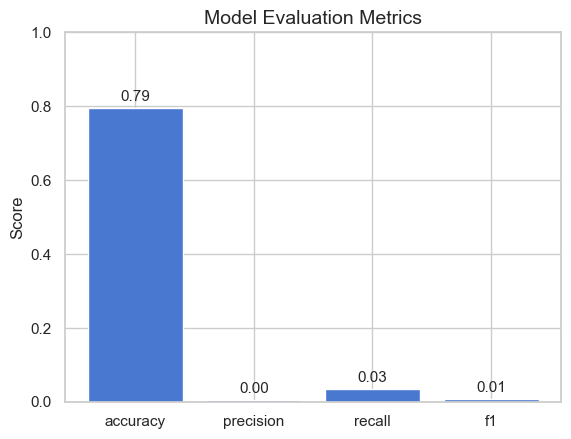

In [53]:
names = list(metrics.keys())
values = list(metrics.values())

plt.figure()
plt.bar(names, values)
plt.title("Model Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)

for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.show()

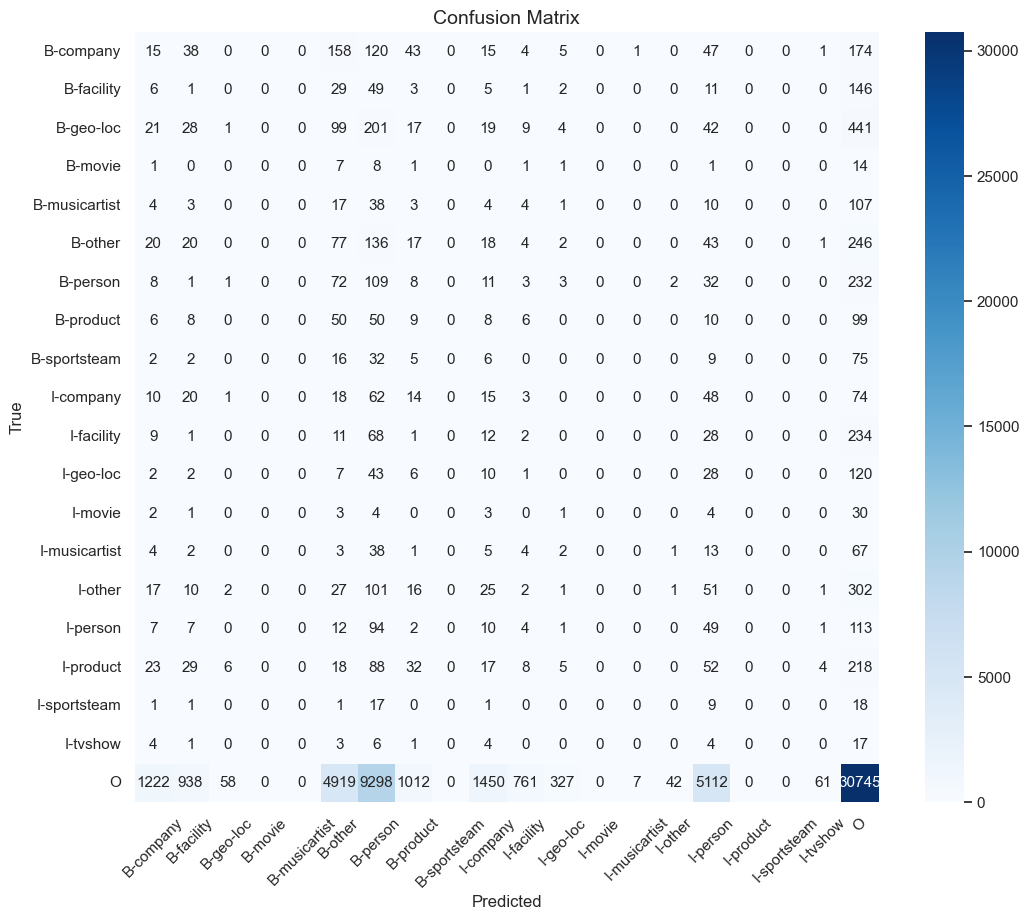

In [55]:
# Flatten sequences

true_flat = [t for seq in all_true for t in seq]
pred_flat = [p for seq in all_pred for p in seq]

# Sort labels (important)
labels = sorted(list(set(true_flat)))

# OPTIONAL: remove 'O'
# labels = [l for l in labels if l != "O"]

# Confusion matrix
cm = confusion_matrix(true_flat, pred_flat, labels=labels)

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels,
            yticklabels=labels,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

In [56]:
MODEL_NAME = 'bert-base-uncased'

In [57]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME) # Load bert-base-uncased tokenizer

In [58]:
sample=train_samples[10] # Random tokenized sample
for token, tag in sample:
  for subtoken in tokenizer(token)['input_ids'][1:-1]:
    print(token,subtoken)

RT 19387
@Hatshepsutely 1030
@Hatshepsutely 16717
@Hatshepsutely 5369
@Hatshepsutely 4523
@Hatshepsutely 10421
@Hatshepsutely 2135
: 1024
@adamlambert 1030
@adamlambert 4205
@adamlambert 10278
@adamlambert 8296
please 3531
, 1010
oh 2821
please 3531
wear 4929
the 1996
infamous 14429
beach 3509
hat 6045
tonight 3892
during 2076
your 2115
encore 19493
( 1006
in 1999
lieu 22470
of 1997
a 1037
rasta 20710
rasta 2696
wig) 24405
wig) 1007
. 1012
&lt; 1004
&lt; 8318
&lt; 1025
3333 21211
3333 2509


In [59]:
def tokenize_sample(sample):
  # Expand label to all subtokens and add 'O' label to start and end tokens
  seq = [
    (subtoken, tag)
    for token, tag in sample
    for subtoken in tokenizer(token.lower())['input_ids'][1:-1]
  ]
  return [(3, 'O')] + seq + [(4, 'O')]

def preprocess(samples, tag2id):
  tokenized_samples = list((map(tokenize_sample, samples)))
  max_len = max(map(len, tokenized_samples))

  # Subtokens
  X_input_ids = np.zeros((len(samples), max_len), dtype=np.int32)

  # Masks
  X_input_masks = np.zeros((len(samples), max_len), dtype=np.int32)

  # labels
  y = np.zeros((len(samples), max_len), dtype=np.int32)

  for i, sentence in enumerate(tokenized_samples):
    for j in range(len(sentence)):
      X_input_masks[i, j] = 1
    for j, (subtoken_id, tag) in enumerate(sentence):
      X_input_ids[i, j] = subtoken_id
      y[i, j] = tag2id[tag]
  return (X_input_ids, X_input_masks), y

X_train, y_train = preprocess(train_samples, tag2id)
X_test, y_test = preprocess(test_samples, tag2id)

In [60]:
# Create config
config = AutoConfig.from_pretrained(
    MODEL_NAME,
    num_labels=len(schema),
    id2label=id2tag,
    label2id=tag2id
)

# Load model
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    config=config
)

print(model)

Loading weights: 100%|█████████████████████████████████████████████████████████████| 197/197 [00:00<00:00, 2321.00it/s]
[transformers] BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignore

BertForTokenClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), ep

In [80]:
model = AutoModelForTokenClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(tag2id),
    id2label=id2tag,
    label2id=tag2id
)
model.to(device)

Loading weights: 100%|█████████████████████████████████████████████████████████████| 197/197 [00:00<00:00, 1179.86it/s]
[transformers] BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignore

BertForTokenClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), ep

In [81]:
optimizer = AdamW(model.parameters(), lr=2e-5)

for epoch in range(5):  # keep smaller for fair comparison
    model.train()
    total_loss = 0

    for batch in train_loader:
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}: Loss = {total_loss/len(train_loader):.4f}")

Epoch 1: Loss = 0.5751
Epoch 2: Loss = 0.1879
Epoch 3: Loss = 0.1110
Epoch 4: Loss = 0.0888
Epoch 5: Loss = 0.0758


In [83]:
model.to(device)

BertForTokenClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), ep

In [84]:
model.eval()

BertForTokenClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), ep

In [85]:

# =============================
# ✅ 4. Create DataLoaders
# =============================
train_dataset = TensorDataset(
    torch.tensor(X_train[0]),
    torch.tensor(X_train[1]),
    torch.tensor(y_train)
)

test_dataset = TensorDataset(
    torch.tensor(X_test[0]),
    torch.tensor(X_test[1]),
    torch.tensor(y_test)
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)


In [87]:
all_logits = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        all_logits.extend(logits.cpu().numpy())

In [88]:
def aggregate(sample, predictions):
    results = []
    i = 1  # skip [CLS]

    for token, y_true in sample:
        n_subtokens = len(tokenizer(token.lower())['input_ids']) - 2

        pred = predictions[i:i+n_subtokens]
        i += n_subtokens

        if len(pred) == 0:
            continue

        scores = np.mean(pred, axis=0)
        y_pred = schema[np.argmax(scores)]

        results.append((token, y_true, y_pred))

    return results

In [89]:
bert_predictions = [
    aggregate(sample, preds)
    for sample, preds in zip(test_samples, all_logits)
]

In [90]:
true_labels_bert = [[t for _, t, _ in sent] for sent in bert_predictions]
pred_labels_bert = [[p for _, _, p in sent] for sent in bert_predictions]

### Evaluate BERT

In [91]:
print("===== BERT RESULTS =====")
print(classification_report(true_labels_bert, pred_labels_bert))
bert_f1 = f1_score(true_labels_bert, pred_labels_bert)
print("BERT F1:", bert_f1)

===== BERT RESULTS =====


C:\Users\SamareshPradhan\AppData\Local\Programs\Python\Python311\Lib\site-packages\seqeval\metrics\v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

     company       0.00      0.00      0.00       621
    facility       0.00      0.00      0.00       253
     geo-loc       0.20      0.38      0.27       882
       movie       0.00      0.00      0.00        34
 musicartist       0.00      0.00      0.00       191
       other       0.07      0.01      0.02       584
      person       0.17      0.42      0.24       482
     product       0.00      0.00      0.00       246
  sportsteam       0.00      0.00      0.00       147
      tvshow       0.00      0.00      0.00        33

   micro avg       0.19      0.16      0.17      3473
   macro avg       0.04      0.08      0.05      3473
weighted avg       0.09      0.16      0.11      3473

BERT F1: 0.17117117117117117


### Evaluate CRF

In [108]:
def extract_data(samples):
    sentences = []
    labels = []

    for sample in samples:
        tokens = [token for token, tag in sample]
        tags = [tag for token, tag in sample]

        sentences.append(tokens)
        labels.append(tags)

    return sentences, labels

train_sentences, train_labels = extract_data(train_samples)
test_sentences, test_labels = extract_data(test_samples)

train_texts = [" ".join(sent) for sent in train_sentences]
test_texts  = [" ".join(sent) for sent in test_sentences]

In [111]:
X_train_seq = crf_tokenizer.texts_to_sequences(train_texts)
X_test_seq  = crf_tokenizer.texts_to_sequences(test_texts)

MAX_LEN = 75

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post')

# ✅ FIXED label mapping
tag2id = {tag: i+1 for i, tag in enumerate(schema)}
tag2id["PAD"] = 0

id2tag = {i: tag for tag, i in tag2id.items()}

def encode_labels(labels, tag2id, max_len):
    encoded = []

    for seq in labels:
        enc = [tag2id[tag] for tag in seq]
        enc = enc[:max_len] + [0]*(max_len - len(enc))   # ✅ safe padding
        encoded.append(enc)

    return np.array(encoded)

y_train = encode_labels(train_labels, tag2id, MAX_LEN)
y_test  = encode_labels(test_labels, tag2id, MAX_LEN)


In [114]:
crf_outputs = crf_model.predict(X_test_pad, verbose=0)
crf_outputs

[array([[[-0.05433185, -0.0860485 ,  0.09426767, ...,  0.03088609,
           0.15192641,  0.0203803 ],
         [ 0.00054083, -0.094099  ,  0.1041036 , ...,  0.04677797,
           0.14279407,  0.05183033],
         [ 0.01744692, -0.08960206,  0.119212  , ...,  0.06018457,
           0.14168057,  0.07412194],
         ...,
         [-0.05379518,  0.00056572,  0.0086435 , ..., -0.02897721,
           0.02825883, -0.02162459],
         [-0.05379518,  0.00056572,  0.0086435 , ..., -0.02897721,
           0.02825883, -0.02162459],
         [-0.05379518,  0.00056572,  0.0086435 , ..., -0.02897721,
           0.02825883, -0.02162459]],
 
        [[-0.0686024 , -0.06061428,  0.07669625, ...,  0.01846093,
           0.14499217, -0.00062111],
         [-0.0133807 , -0.0716598 ,  0.09271363, ...,  0.0088879 ,
           0.12927139,  0.04051275],
         [-0.00693617, -0.07329866,  0.09948106, ...,  0.00242132,
           0.13700308,  0.04940437],
         ...,
         [-0.05379518,  0.0005657

In [122]:
print("===== LSTM + CRF RESULTS =====")

crf_outputs = crf_model.predict(X_test_pad, verbose=0)

# ✅ FIXED extraction
crf_preds = crf_outputs[1][0]

all_true = []
all_pred = []

for true_seq, pred_seq in zip(y_test, crf_preds):

    true_sent = []
    pred_sent = []

    for t, p in zip(true_seq, pred_seq):
        if t == 0:
            continue

        true_sent.append(id2tag[int(t)])
        pred_sent.append(id2tag[int(p)])

    all_true.append(true_sent)
    all_pred.append(pred_sent)

precision = precision_score(all_true, all_pred)
recall = recall_score(all_true, all_pred)
f1 = f1_score(all_true, all_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\n===== Classification Report =====")
print(classification_report(all_true, all_pred))


===== LSTM + CRF RESULTS =====


C:\Users\SamareshPradhan\AppData\Local\Programs\Python\Python311\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: PAD seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))


Precision: 0.0054
Recall   : 0.0608
F1 Score : 0.0099

===== Classification Report =====


C:\Users\SamareshPradhan\AppData\Local\Programs\Python\Python311\Lib\site-packages\seqeval\metrics\v1.py:57: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

          AD       0.00      0.00      0.00         0
     company       0.01      0.09      0.01       621
    facility       0.00      0.00      0.00       253
     geo-loc       0.01      0.14      0.02       882
       movie       0.00      0.00      0.00        34
 musicartist       0.00      0.01      0.00       191
       other       0.01      0.02      0.01       584
      person       0.00      0.00      0.00       482
     product       0.00      0.06      0.01       246
  sportsteam       0.00      0.01      0.00       147
      tvshow       0.00      0.00      0.00        33

   micro avg       0.01      0.06      0.01      3473
   macro avg       0.00      0.03      0.01      3473
weighted avg       0.01      0.06      0.01      3473



In [124]:
print("===== LSTM + CRF RESULTS =====")

# ✅ Use the correct variables
print(classification_report(all_true, all_pred))

crf_precision = precision_score(all_true, all_pred)
crf_recall = recall_score(all_true, all_pred)
crf_f1 = f1_score(all_true, all_pred)

print(f"Precision: {crf_precision:.4f}")
print(f"Recall   : {crf_recall:.4f}")
print(f"F1 Score : {crf_f1:.4f}")

===== LSTM + CRF RESULTS =====
              precision    recall  f1-score   support

          AD       0.00      0.00      0.00         0
     company       0.01      0.09      0.01       621
    facility       0.00      0.00      0.00       253
     geo-loc       0.01      0.14      0.02       882
       movie       0.00      0.00      0.00        34
 musicartist       0.00      0.01      0.00       191
       other       0.01      0.02      0.01       584
      person       0.00      0.00      0.00       482
     product       0.00      0.06      0.01       246
  sportsteam       0.00      0.01      0.00       147
      tvshow       0.00      0.00      0.00        33

   micro avg       0.01      0.06      0.01      3473
   macro avg       0.00      0.03      0.01      3473
weighted avg       0.01      0.06      0.01      3473

Precision: 0.0054
Recall   : 0.0608
F1 Score : 0.0099


In [125]:
print("\n========== MODEL COMPARISON ==========")
print(f"BERT F1 Score     : {bert_f1:.4f}")
print(f"LSTM+CRF F1 Score : {crf_f1:.4f}")

if bert_f1 > crf_f1:
    print("✅ BERT performs better")
else:
    print("✅ LSTM+CRF performs better")


========== MODEL COMPARISON ==========
BERT F1 Score     : 0.1712
LSTM+CRF F1 Score : 0.0099
✅ BERT performs better


Additional Work

In [127]:
from transformers import AutoTokenizer

# Initialize a tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_and_align_labels(sentence_tokens, tags, tag_to_id):
    tokenized_inputs = tokenizer(sentence_tokens, truncation=True, is_split_into_words=True)
    labels = []
    word_ids = tokenized_inputs.word_ids()
    previous_word_idx = None
    for word_idx in word_ids:
        if word_idx is None:
            labels.append(-100)
        elif word_idx != previous_word_idx:
            labels.append(tag_to_id[tags[word_idx]])
        else:
            labels.append(tag_to_id[tags[word_idx]] if tags[word_idx].startswith("I-") else -100)
        previous_word_idx = word_idx
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

tag_to_id = {tag: i for i, tag in enumerate(schema)}
id_to_tag = {i: tag for tag, i in tag_to_id.items()}

train_processed = []
for sample in train_samples:
    tokens = [item[0] for item in sample]
    tags = [item[1] for item in sample]
    train_processed.append(tokenize_and_align_labels(tokens, tags, tag_to_id))

test_processed = []
for sample in test_samples:
    tokens = [item[0] for item in sample]
    tags = [item[1] for item in sample]
    test_processed.append(tokenize_and_align_labels(tokens, tags, tag_to_id))

print("Example of tokenized and aligned data for training:")
print(train_processed[0])

Example of tokenized and aligned data for training:
{'input_ids': [101, 1030, 3520, 9856, 27610, 25855, 2213, 1030, 1056, 2290, 10790, 2581, 2620, 2487, 2027, 2097, 2022, 2035, 2589, 2011, 4465, 3404, 2033, 1008, 16837, 1008, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'labels': [-100, 8, -100, -100, -100, -100, -100, 8, -100, -100, -100, -100, -100, -100, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, -100, -100, -100]}


In [128]:
import torch
from torch.utils.data import DataLoader
from transformers import DataCollatorForTokenClassification

class NERDataset(torch.utils.data.Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __getitem__(self, idx):
        # Correctly access the dictionary for the given index and convert its values to tensors
        item = {key: torch.tensor(val) for key, val in self.encodings[idx].items()}
        return item

    def __len__(self):
        # Correctly return the length of the list of encodings
        return len(self.encodings)

# Convert processed data into datasets
train_dataset = NERDataset(train_processed)
test_dataset = NERDataset(test_processed)

# Initialize data collator
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

# Create DataLoaders
train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=16, collate_fn=data_collator)
test_dataloader = DataLoader(test_dataset, batch_size=16, collate_fn=data_collator)

print("Train dataset size:", len(train_dataset))
print("Test dataset size:", len(test_dataset))

Train dataset size: 2394
Test dataset size: 3850


In [129]:
# Define the model
model = BertForTokenClassification.from_pretrained(
    "bert-base-uncased", num_labels=len(tag_to_id), id2label=id_to_tag, label2id=tag_to_id
)

# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch", # Changed from evaluation_strategy
    learning_rate=2e-5,
    per_device_train_batch_size=8, # Reduced from 16 to 8 for faster training
    per_device_eval_batch_size=8,  # Reduced from 16 to 8 for faster evaluation
    num_train_epochs=1, # Reduced from 3 to 1 for faster training
    weight_decay=0.01,
)

# Define metrics computation function
def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_labels = [[id_to_tag[l] for l in label if l != -100] for label in labels]
    true_predictions = [
        [id_to_tag[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    report = classification_report(true_labels, true_predictions, output_dict=True)
    return {
        "precision": report["micro avg"]["precision"],
        "recall": report["micro avg"]["recall"],
        "f1": report["micro avg"]["f1-score"], # Changed 'f1' to 'f1-score'
    }

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    # tokenizer=tokenizer, # Removed this argument
    compute_metrics=compute_metrics,
)

print("Model, TrainingArguments, and Trainer initialized.")

Loading weights: 100%|█████████████████████████████████████████████████████████████| 197/197 [00:00<00:00, 2041.34it/s]
[transformers] BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignore

Model, TrainingArguments, and Trainer initialized.


In [130]:
trainer.train()

C:\Users\SamareshPradhan\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,No log,0.436347,0.223330,0.148287,0.178232


Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.17s/it]
C:\Users\SamareshPradhan\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\SamareshPradhan\AppData\Local\Programs\Python\Python311\Lib\site-packages\seqeval\metrics\v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


TrainOutput(global_step=300, training_loss=0.331711908976237, metrics={'train_runtime': 1362.8259, 'train_samples_per_second': 1.757, 'train_steps_per_second': 0.22, 'total_flos': 58486421860308.0, 'train_loss': 0.331711908976237, 'epoch': 1.0})

In [150]:
results = trainer.evaluate()
print(results)

C:\Users\SamareshPradhan\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


C:\Users\SamareshPradhan\AppData\Local\Programs\Python\Python311\Lib\site-packages\seqeval\metrics\v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Training Loss,Validation Loss,Epoch,Precision,Recall,F1
No log,0.436347,1,0.223330,0.148287,0.178232


{'eval_loss': 0.43634673953056335, 'eval_precision': 0.22333044232437121, 'eval_recall': 0.14828678376043766, 'eval_f1': 0.17823152794601146}


# Questions

1. Defining the Problem Statement and Where Can This Be Used?

The goal of this project is to build a Named Entity Recognition (NER) system that identifies entities such as people, locations, companies, and products from Twitter text. It can be used in social media monitoring, customer sentiment analysis, chatbots, recommendation systems, and information extraction applications.

2. Explain the Data Format (CoNLL BIO Format)

The dataset follows the CoNLL BIO format, where each token is assigned a tag. "B" denotes the beginning of an entity, "I" denotes a token inside an entity, and "O" denotes a token outside any entity. This format helps the model identify both entity types and their boundaries.

3. What Other NER Annotation Formats Are Available and How Are They Different?

Common alternatives include BIOES/BILOU, IO, and span-based annotation formats. BIOES provides more detailed boundary information using Begin, Inside, End, and Single tags, while span-based formats store entity start and end positions instead of token-level labels.

4. Why Do We Need Tokenization of the Data?

Tokenization converts raw text into smaller units that machine learning models can process. In BERT, tokenization also handles unknown and rare words using subword tokens, improving vocabulary coverage and model performance.

5. What Other Models Can Be Used for This Task?

Apart from BiLSTM-CRF and BERT, NER can be implemented using CRF, HMM, CNN-BiLSTM, RoBERTa, DistilBERT, ALBERT, DeBERTa, and ELECTRA. Transformer-based models generally achieve higher accuracy due to their ability to capture contextual information.

6. Did Early Stopping Have Any Effect on the Training and Results?

Early stopping monitors validation performance and stops training when improvements stop occurring. It helps prevent overfitting and reduces unnecessary training time. In this project, it likely improved model generalization while saving computational resources.

7. How Does the BERT Model Expect a Pair of Sentences to Be Processed?

BERT processes sentence pairs by inserting special tokens: [CLS] at the beginning and [SEP] between sentences. It also uses segment embeddings to distinguish the two sentences, allowing the model to learn relationships between them.

8. Why Choose Attention-Based Models Over Recurrent-Based Ones?

Attention-based models can process all tokens simultaneously, making training faster and more scalable than recurrent models. They also capture long-range dependencies more effectively, leading to better performance on most NLP tasks.

9. Differentiate BERT and Simple Transformers

A simple transformer consists of encoder and decoder components and is primarily designed for sequence-to-sequence tasks. BERT uses only the encoder and is pre-trained on large text corpora using Masked Language Modeling, making it highly effective for language understanding tasks such as NER.